In [1]:
import nugget
import numpy as np
import importlib
import pickle
import torch
import matplotlib.pyplot as plt
import os
import scipy

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


alpha = 1.1839731036473282, b_eff(400) = 0.003538239121146255 1/m, R^2 = 0.9999999999999998
kappa = 4.306201799533186, a(400) = 0.060008562759480744 1/m, R^2 = 1.0
Effective scattering length at 450nm: 324.9 m
Scattering length at 450nm: 64.32 m
Absorption length at 450nm: 27.67 m


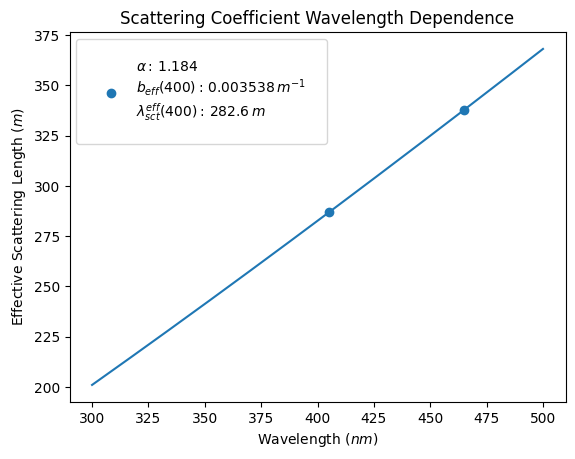

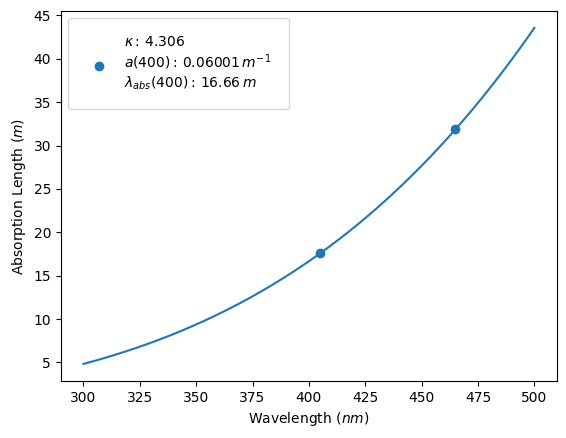

In [17]:
from scipy.stats import linregress

# STRAW model data April 2019
edaVals = np.array([14, 15, 10.6])
eda = (sum(edaVals) / len(edaVals)) / 100
scatteringL = np.array([56.78, 66.87])
averageAngle = (1 - eda) * 0.924
effectiveScatteringL = scatteringL / (1 - averageAngle)
effScatteringCoeff = 1 / effectiveScatteringL

absorptionCoeff = np.array([1 / 17.58, 1 / 31.87])
wavelengths = np.array([405, 465])

x_scat = np.log(wavelengths / 400.0)
y_scat = np.log(effScatteringCoeff)
scat_fit = linregress(x_scat, y_scat)

x_abs = np.log(wavelengths / 400.0)
y_abs = np.log(absorptionCoeff)
abs_fit = linregress(x_abs, y_abs)

alpha = -scat_fit.slope  # scattering wavelength dependence power law exponent
kappa = -abs_fit.slope   # absorption wavelength dependence power law exponent
b_e_400 = np.e ** scat_fit.intercept
a_e_400 = np.e ** abs_fit.intercept

print(f"alpha = {alpha}, b_eff(400) = {b_e_400} 1/m, R^2 = {scat_fit.rvalue**2}")
print(f"kappa = {kappa}, a(400) = {a_e_400} 1/m, R^2 = {abs_fit.rvalue**2}")

x = np.linspace(300, 500, 201)

plt.figure()
y = b_e_400 * (x / 400) ** scat_fit.slope
plt.plot(x, 1/y)
plt.scatter(
    wavelengths,
    1/effScatteringCoeff,
    label=(
        r"$\alpha:\,$" + f"{alpha:.4g}\n"
        + r"$b_{eff}(400):\,$" + f"{b_e_400:.4g}" + r"$\,m^{-1}$" + "\n"
        + r"$\lambda_{sct}^{eff}(400):\,$" + f"{1/b_e_400:.4g}" + r"$\,m$"
    ),
)
#print closest value to 450nm
print(f"Effective scattering length at 450nm: {1/(b_e_400 * (450 / 400) ** scat_fit.slope):.4g} m")
#print scattering length at 450nm
print(f"Scattering length at 450nm: {1*(1 - averageAngle)/(b_e_400 * (450 / 400) ** scat_fit.slope):.4g} m")
plt.title("Scattering Coefficient Wavelength Dependence")
plt.xlabel(r"Wavelength $(nm)$")
plt.ylabel(r"Effective Scattering Length $(m)$")
plt.legend(borderpad=1.5)

plt.figure()
y = a_e_400 * (x / 400) ** abs_fit.slope
plt.plot(x, 1/y)
plt.scatter(
    wavelengths,
    1/absorptionCoeff,
    label=(
        r"$\kappa:\,$" + f"{kappa:.4g}\n"
        + r"$a(400):\,$" + f"{a_e_400:.4g}" + r"$\,m^{-1}$" + "\n"
        + r"$\lambda_{abs}(400):\,$" + f"{1/a_e_400:.4g}" + r"$\,m$"
    ),
)
print(f"Absorption length at 450nm: {1/(a_e_400 * (450 / 400) ** abs_fit.slope):.4g} m")
# plt.title("Absorption Coefficient Wavelength Dependence")
plt.xlabel(r"Wavelength $(nm)$")
plt.ylabel(r"Absorption Length $(m)$")
plt.legend(borderpad=1.25)

plt.show()

In [2]:
device = 'cuda:1'
lightsabre_surrogate = nugget.surrogates.LightSabre.LightSabre(
                                        device=device, 
                                        use_poisson=False, 
                                        domain_size=2000,
                                        particle_mode='track',
                                        )
cascade_surrogate = nugget.surrogates.LightSabre.LightSabre(
                                        device=device, 
                                        use_poisson=False, 
                                        domain_size=2000,
                                        particle_mode='cascade',
                                        )
patd_surrogate = nugget.surrogates.LightSabre.LightSabrePATD(
                                        device=device,
                                        use_poisson=False,
                                        num_track_points=1000,
                                        domain_size=2000,
                                        use_max_energy_dist=True,
                                        use_perpendicular_distance_only=True,
                                        particle_mode='track',
                                        )
patd_light_yield_surrogate = patd_surrogate.light_yield_surrogate
track_light_yield_surrogate = lightsabre_surrogate.light_yield_surrogate
cascade_light_yield_surrogate = cascade_surrogate.light_yield_surrogate
batched_track_surrogate = lightsabre_surrogate.light_yield_surrogate_batched
# light_yield_surrogate = nugget.surrogates.Uniform.Uniform()
# Initialize event samplers for signal and background events
signal_sampler = nugget.samplers.cyl_sampler.CylinderSampler(
                                        device=None, 
                                        event_type='signal', 
                                        domain_size=2000, 
                                        E_min=1e2, 
                                        E_max=1e8, 
                                        find_exact_intersection=False,
                                        random_position_along_ray=True,  
                                        energy_dist='log_uniform',
                                        cylinder_radius=600,
                                        cylinder_height=1000,
                                        uniform_zenith_sampling=True,
                                        cos_range=[-1,0]
                                        )

In [26]:
importlib.reload(nugget.utils.basic_evaluator)
importlib.reload(nugget.utils.vis_tools)
importlib.reload(nugget.geometries.EvanescentString)
importlib.reload(nugget.geometries.DynamicString)
# geometry = nugget.geometries.EvanescentString.EvanescentString(
#             device=device,
#             hex_type='hexagonal',
#             domain_size=1600,  # Size of detector domain
#             dim=3,  # 3D geometry
#             n_strings=1027,  # Initial number of detector strings (ignore)
#             points_per_string=20,  # Number of OMs per string
#             custom_z_spacing=50, # OM spacing along string
#             starting_weight =1000,
#             active_weights_mode=True
#         )
geometry = nugget.geometries.DynamicString.DynamicString(
            device=device,
            hex_type='hexagonal',
            domain_size=1600,  # Size of detector domain
            dim=3,  # 3D geometry
            n_strings=1027,  # Initial number of detector strings (ignore)
            points_per_string=20,  # Number of OMs per string
            custom_z_spacing=50, # OM spacing along string
)

visualizer = nugget.utils.vis_tools.Visualizer(
    device=device,
    dim=3, 
    domain_size=2500,
    )

evaluator = nugget.utils.basic_evaluator.Evaluator(
    device=device,
    geometry=geometry,
    visualizer=visualizer,
)

In [4]:
test_signal_events = signal_sampler.sample_events(num_events=100000)
# test_signal_events = pickle.load(open('/u/kristiantcho/ptmp/nugget/nugget/examples/res_test/signal_events_30000_r600_50_pl_1.pkl', 'rb'))
# test_signal_events = nugget.utils.data_tools.load_signal_events_parquet('/u/kristiantcho/ptmp/nugget/nugget/examples/res_test/signal_events_50000_r600_50_u_1.pt')

In [30]:
importlib.reload(nugget.losses.geometry_penalties)
importlib.reload(nugget.losses.fisher_info)
importlib.reload(nugget.losses.pointsource_fom)
rov_penalty = nugget.losses.geometry_penalties.ROVPenalty(
    device=geometry.device, 
    rov_rec_width=230,  # ROV dimensions
    rov_height=159.9, 
    rov_tri_length=159.9
)

angular_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    device=geometry.device,
    # device="cuda:3",
    resolution_type='angular',
    fisher_info_params=['position', 'direction']
)

energy_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    device=geometry.device,
    # device="cuda:3",
    resolution_type='energy',
    fisher_info_params=['position', 'energy']
)
trigger_loss = nugget.losses.trigger.TriggerLoss(
    device=geometry.device,
    light_yield_threshold=6.0,
    distance_bar_length=550.0,
    distance_bar_step=40.0,
    min_points_threshold=30.0,
    t1_temperature=5.0,
    t3_temperature=5.0,
    t_temperature=5.0, 
    use_hard_cuts=True,
)
effective_area_loss = nugget.losses.effective_area.EffectiveAreaLoss(
    device=geometry.device,
    domain_size=1200,
    trigger=trigger_loss
    )

pointsource_fom_loss = nugget.losses.pointsource_fom.FoMLoss(
    device=geometry.device,
    fisher_info_params=['position', 'direction'],
    effective_area_loss=effective_area_loss
)

loss_params = {
 # 'llr_net': llr_net,
    'signal_event_params': test_signal_events,
    # 'signal_event_params': nugget.utils.data_tools.load_signal_events_parquet(f'res_test/signal_events/signal_events_{total_events}_{events_version}.pt'),  # Pre-sampled signal events for loss computation
    # 'signal_event_params': nugget.utils.data_tools.select_events(nugget.utils.data_tools.load_signal_events_parquet(f'res_test/signal_events_{total_events}_{events_version}.pt'),limits=selection_limits),  # Pre-sampled signal events for loss computation
    # 'background_event_params': new_background_events,
    'signal_surrogate_func': track_light_yield_surrogate,  # Function to compute light yield
    # 'background_surrogate_func': light_yield_surrogate,
    'signal_sampler': signal_sampler,
    # 'background_sampler': background_sampler,
    'num_events': 100000,  # Number of events to sample per optimization step
    'signal_noise_scale': 0,  # Noise level for signal events
    # 'background_noise_scale': 0.2,  # Noise level for background events
    'boundary_range': 1200,  # Size of boundary region
    'skip_zero_response': False,
    # 'fisher_info_llr_net': llr_net,
    'use_relative_energy': True,
    # 'event_paths': ['/u/kristiantcho/ptmp/nugget/nugget/examples/res_test_signal_events_100_1.pkl'],
    # 'fisher_info_paths': ['/u/kristiantcho/ptmp/nugget/nugget/examples/res_test_fisher_info_per_string_per_event_100_1.pt'],
    # 'sample_every': 50,
    # 'precomputed_signal_yield_per_string': torch.load('res_test/light_yield_per_string_50000_800main_full_hex_r600_50_u_1.pt')[selection_inds],
    # 'llr_event_labels': ['position','energy', 'direction'],
    # 'precomputed_fisher_info_per_string_per_event': fisher_info_precomp#[selection_inds]

    'eva_min_num_strings': 72,  # Minimum number of active strings
    'string_number_use_binarization_weight': False,
    'max_radius': 80,  # Maximum radius for string placement
    'num_angles': 360,  # Number of angles (divided into 360 degrees) to test for rov
    'rov_alt_mode': True,  # Whether to use alternative mode for rov penalty (see rov_penalty.py for details)
    'local_sharpness': 10,  # Sharpness parameter for local string repulsion
    'boundary_sharpness': 10,  # Sharpness parameter for boundary penalty
    'string_number_beta':5,
    'detach_other_probs':False,
    'rov_soft_inside':False,
    'rov_inside_sharpness': 5,
    'rov_angle_softmin_tau': 0.05,
    'rov_angle_chunk_size': 360,
    'rov_away_weight': 0.00,
    'rov_away_num_neighbours':5,
    'rov_use_torch_compile': False,
    'local_repulsion_use_torch_compile': False,
    'rov_inside_use_softplus': True,


    # 'other_geoms':[pickle.load(open('./800main_full_hex_r600_50_pl_1_ang_res_rov/geom_17.pkl', 'rb'))],
    'diversity_use_hungarian': True,
    'diversity_use_sinkhorn':False,
    'diversity_min':1,
    'sinkhorn_niter':10,
    'sinkhorn_epsilon':0.5,
    'diversity_use_mmd':False,
    
    # 'fisher_info_llr_net': llr_net,
    # 'fisher_info_llr_iterations':50,
    # 'llr_event_labels': ['position','energy', 'direction'],
    'fisher_info_grad_chunk_size': 14,
    'fisher_info_jacrev_chunk_size': 50000,
    'fisher_info_point_chunk_size': 40100,
    'fisher_info_llr_autodiff_mode': 'jvp',
    'fisher_info_detach_tensors': False,
    'fisher_info_use_patd': False,
    'fisher_res_metric': 'mean',  # 'fom' 'median' 'mean'
    'fisher_info_use_torch_compile': True,
    # 'eval_patd_log_probs':patd_surrogate.eval_patd_log_probs,
    'use_rich_features': True,
    'use_patd_quadrature': False,
    't_offset_ns': 0.0,
    't_max_ns': 5000.0,
    'use_charge_quadrature': False,
    'charge_center_on_llr_peak': True,
    'charge_peak_scan_points':32,
    'adaptive_grid_retry':True,
    'adaptive_t_max_floor_ns':10,
    'uninformative_fisher_value':1e-6,
    'empty_cache_after_event': True,
    'events_per_batch': 10000,

    'trigger_use_torch_compile': False,
    'use_batched_trigger': True,
    'use_batched_surrogate': True,
    'use_batched_binned_trigger': True,
    'use_batched_effective_area': True,
    'bounding_cylinder_temperature': 1,
    'binned_trigger_batch_size': 1000,

    'perfect_efficiency': True,
    'downweight_untriggerable': False,
    "trigger_neighbor_distance": 550.0,
    "trigger_min_neighbors": 30,
    'trigger_distance_sharpness': 0.05,
    'trigger_count_sharpness':1,
    # 'num_events_per_bin': 100,
    # 'num_energy_bins': 30,
    # 'num_zenith_bins': 30,
    'per_event_effective_area_loss': True,
    'fom_adjust_cylinder_to_geometry':False,
    'fom_include_uniform_log_e_term':False,
    'include_projected_area':True,
    'use_sampler_cyl_for_volume':True,
    'detach_light_yields': True,
    # 'perfect_efficiency': False,
    # 'cos_zenith_range': (-1, 0),
    # 'binned_trigger_batch_size': 500,
    # 'batched_surrogate_func': batched_track_surrogate,
    # 'detach_trigger': False,
    'analysis_adjust_cylinder_to_geometry': False,
    'analysis_signal_flux_var_names': ['astro_norm', 'astro_index'],
    'friend_config': '../other/friend_config.yaml',
    'pyff_config': '../other/pyff_config.yaml',
    'live_time': 10 * 365 * 24 * 60 * 60,  # 10 years in seconds

    'constraints_list': [
                # 'energy_resolution_loss',
                # 'angular_resolution_loss',
                # 'signal_yield_loss', 
                'rov_penalty', 
                # 'string_boundary_penalty', 
                'local_string_repulsion_penalty', 
                'string_number_penalty', 
                # 'string_weights_penalty',
                'weight_binarization_penalty',
                # 'diversity_penalty',
                ],  # Constraints to enforce
}

loss_func_dict = {
    'rov_penalty': rov_penalty,
    # 'angular_resolution_loss': angular_resolution_loss,
    'pointsource_fom_loss': pointsource_fom_loss,
    'energy_resolution_loss': energy_resolution_loss,
}

plot_types = [
    'string_xy',
    'string_xy_rov_penalty',
    'angular_resolution_vs_zenith',
    'angular_resolution_vs_energy',
    'energy_resolution_vs_energy',
    'pointsource_fom_vs_energy',
    'effective_area_vs_energy',
]

vis_kwargs = {
   'moving_average_window': 10,  # Window size for smoothing loss curves
       'moving_average_losses': ['pointsource_fom_loss', 'fisher_analysis_loss'],
       'plot_types': plot_types,
       'slice_res': 51,             # Resolution of spatial plots
       'multi_slice': True,         # Generate multiple depth slices
       'gif_plot_selection': plot_types,  # Which plots to include in animation
       # 'loss_filter': ['string_boundary_penalty'],  # Hide large loss components from loss component plot
       'zoom_range':900,

       'plot_with_surrogate': False,  # Use surrogate function for spatial plots
       # 'signal_yield_per_string': loss_params['precomputed_signal_yield_per_string'],  # Precomputed light yield for visualization
       'n_zenith_bins': 10,  # Binning for angular resolution plots
       'n_energy_bins': 10,   # Binning for energy resolution plots
       'draw_radius': True,
       'draw_weighted_cylinder': True,
       'show_resolution_ci': False,
       'ratio_baseline_geometry': 'large',
       # 'max_radius': loss_params['boundary_range']/2,
       'rov_penalty_func': rov_penalty,
       'resolution_logy_energy': True,
       'use_relative_energy': True,
       'plot_geom_contour_only': True,
       'ps_fom_logy': True,
       'use_log_charge': True,
       'rov_draw_safe_space_union': True,
       'rov_union_per_space_colors':True,
       'rov_draw_safe_space_on_violations':True,
       'resolution_stat': 'mean',  # Statistic to plot for resolution ('median', 'mean', or 'fom')
}

In [8]:
torch.cuda.empty_cache()

In [31]:
geom_dicts = {}
loss_param_dicts = {}
# focus = 'ang_res'
# version = 'r600_50_u_1'
# compare_version = 'r600_50_u_1'
# num_events = 50000
for geom_name in ['default', 'modified', 'expanded', 'compact', 'large', '6fold_72_rov']:
    # if geom_name == '800main_full_hex':
    #     for addon_name in ['_rov', '_no_rov']:
    #         geom_files = sorted([f for f in os.listdir(f'{geom_name}_{compare_version}_{focus}{addon_name}') if f.startswith('geom_') and f.endswith('.pkl')],
    #                     key=lambda x: int(x.split('_')[1].split('.')[0]))
    #         geom_dict = pickle.load(open(f'{geom_name}_{compare_version}_{focus}{addon_name}/{geom_files[-1]}', 'rb'))
    #         geom_name_full = geom_name + addon_name
    #         geom_dicts[geom_name_full] = geom_dict
    #         # IMPORTANT: copy loss_params per-geometry so we don't overwrite the same dict
    #         loss_param_dicts[geom_name_full] = dict(loss_params)
    #         loss_param_dicts[geom_name_full]['precomputed_fisher_info_per_string_per_event'] = torch.load(
    #             f'res_test/fisher_info_per_string_per_event_{num_events}_{geom_name}_{version}.pt'
    #         )
    #     continue

    # temp_name = '340grid'
    # string_xy = np.load(f'../other/{temp_name}_xy.npy')
    if '6fold_72' not in geom_name:
        highlight_xy = np.load(f'../other/{geom_name}_xy.npy')
    # string_weights = np.ones(string_xy.shape[0])*(-1000)
    # Match each highlight point to the closest string (robust to small float differences)
    # diffs = string_xy[None, :, :] - highlight_xy[:, None, :]   # (n_highlight, n_strings, 2)
    # dists = np.linalg.norm(diffs, axis=2)                      # (n_highlight, n_strings)
    # closest_idx = np.argmin(dists, axis=1)
    # string_weights[np.unique(closest_idx)] = 1000
    # geom_dict = {'string_xy': string_xy, 'string_weights': string_weights}
    # elif geom_name == '600hexagon':
    #     geom_dict = {'n_strings': 70}
        geom_dict = {'string_xy': torch.tensor(highlight_xy)}
    else:
        if 'no_rov' not in geom_name:
            geom_dict = pickle.load(open('best_geom_pl_ps_fom_72_6fold_rov_no_eff.pkl', 'rb'))
        else:
            geom_dict = pickle.load(open('best_geom_pl_ps_fom_72_6fold_no_rov_no_eff.pkl', 'rb'))
        #detach geometry from old gpu and save
        # for key in geom_dict.keys():
        #     geom_dict[key] = geom_dict[key].detach().cpu()
        # pickle.dump(geom_dict, open('best_geom_pl_ps_fom_72_6fold_rov.pkl', 'wb'))
    geom_dicts[geom_name] = geom_dict
    # IMPORTANT: copy loss_params per-geometry so we don't overwrite the same dict
    loss_param_dicts[geom_name] = dict(loss_params)
    # loss_param_dicts[geom_name]['precomputed_fisher_info_per_string_per_event'] = torch.load(
    #     f'res_test/fisher_info_per_string_per_event_{num_events}_{temp_name}_{version}.pt'
    # )

In [ ]:
geom_dicts = {}
loss_param_dicts = {}
for geom_name in ['800main']:
    for extra_addon_name in ['', '_e2_e4', '_e6_e8']:
    # for extra_addon_name in ['', '_z155_z180', '_z70_z110']:
        for addon_name in ['_rov', '_no_rov']:
            geom_files = sorted([f for f in os.listdir(f'{geom_name}_r600_50{extra_addon_name}_1_ang_res{addon_name}') if f.startswith('geom_') and f.endswith('.pkl')],
                        key=lambda x: int(x.split('_')[1].split('.')[0]))
            geom_dict = pickle.load(open(f'{geom_name}_r600_50{extra_addon_name}_1_ang_res{addon_name}/{geom_files[-1]}', 'rb'))
            geom_dicts[geom_name+extra_addon_name+addon_name] = geom_dict
            # IMPORTANT: copy loss_params per-geometry so we don't overwrite the same dict
            loss_param_dicts[geom_name+extra_addon_name+addon_name] = dict(loss_params)
            
            # if addon_name == '_e2_e4' or addon_name == '_e6_e8' or extra_addon_name == '_z155_z180' or extra_addon_name == '_z70_z110':
            #     loss_param_dicts[geom_name+extra_addon_name+addon_name]['signal_event_params'] = pickle.load(
            #         open(f'res_test/signal_events_10000_r600_50{extra_addon_name}_1.pkl', 'rb'))
            #     loss_param_dicts[geom_name+extra_addon_name+addon_name]['precomputed_fisher_info_per_string_per_event'] = torch.load(
            #         f'res_test/fisher_info_per_string_per_event_10000_800main_r600_50{extra_addon_name}_1.pt')  
            # else:

In [ ]:
results = evaluator.evaluate(
    geom_dict=geom_dicts['800main'],
    loss_func_dict=loss_func_dict,
    loss_params_dict=loss_param_dicts['600hexagon'],
    vis_kwargs=vis_kwargs,
    visualize=True,
)

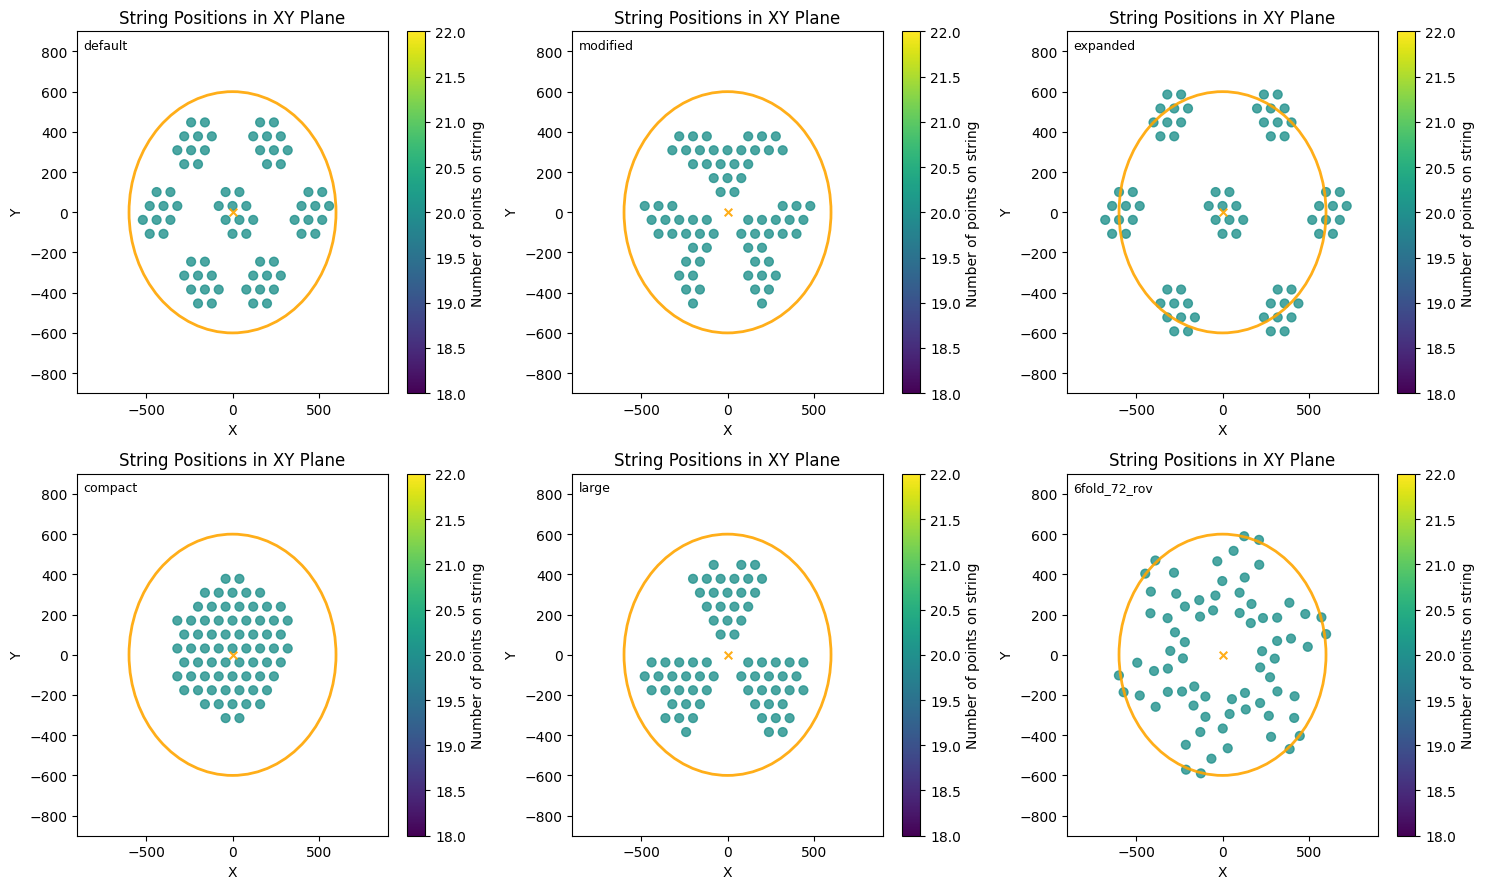

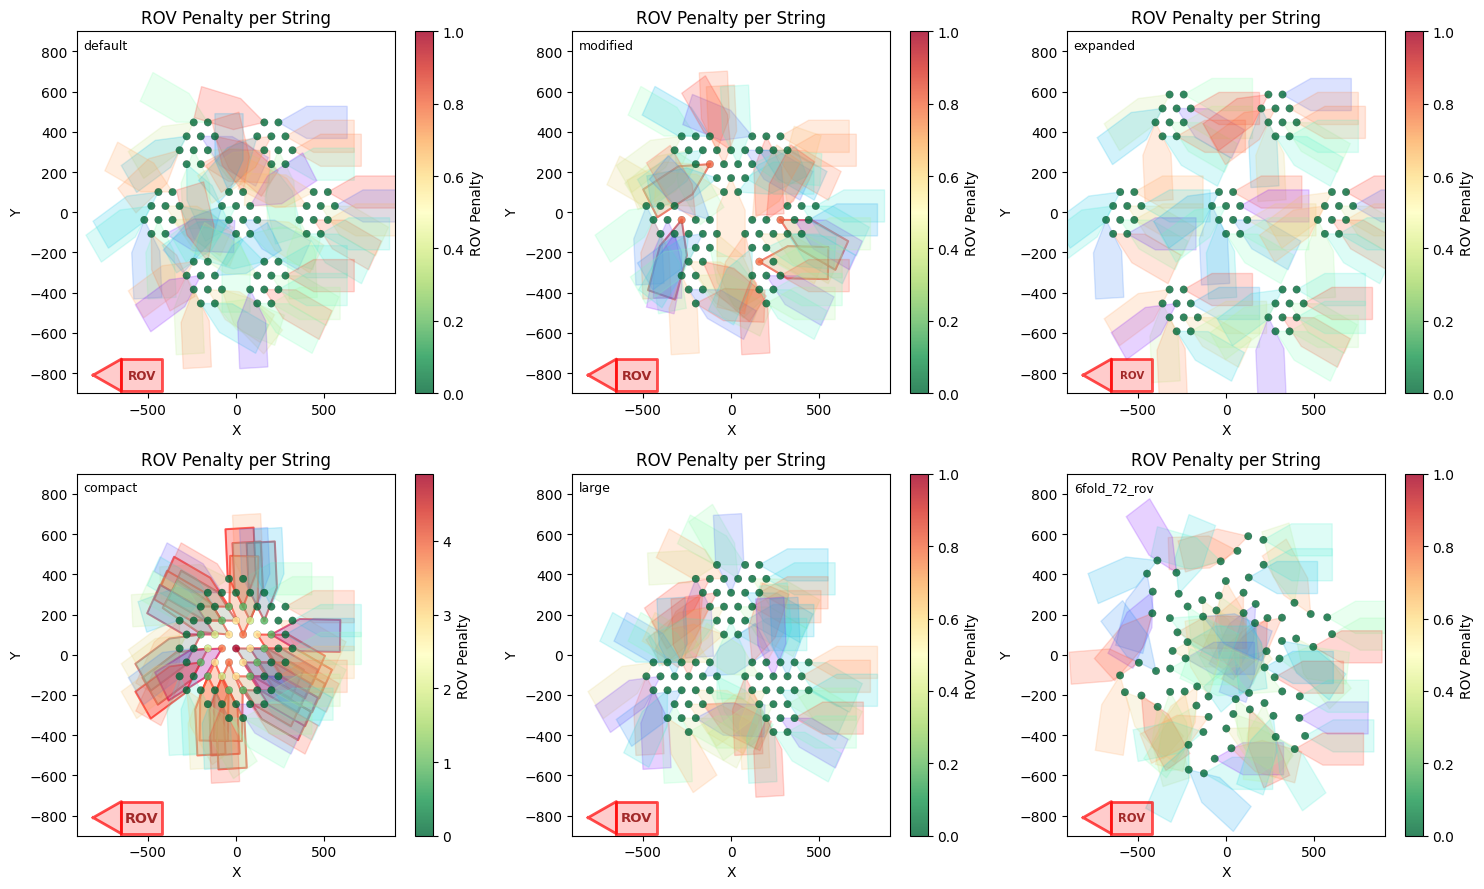

/ptmp/mpp/kristiantcho/nugget/nugget/utils/vis_tools.py:2969: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  loss_type=per_loss_type,


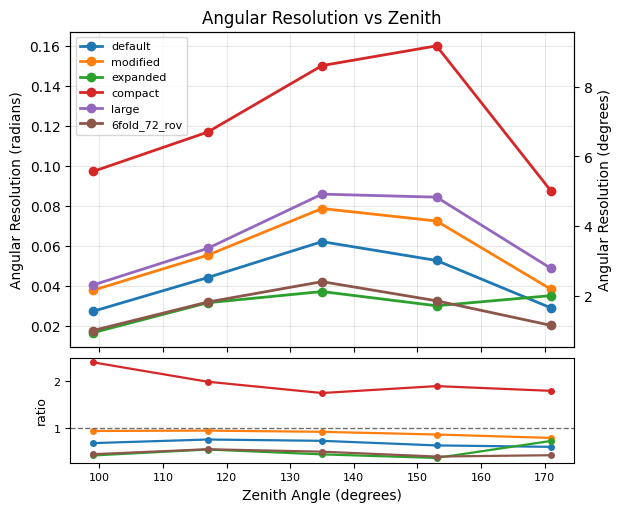

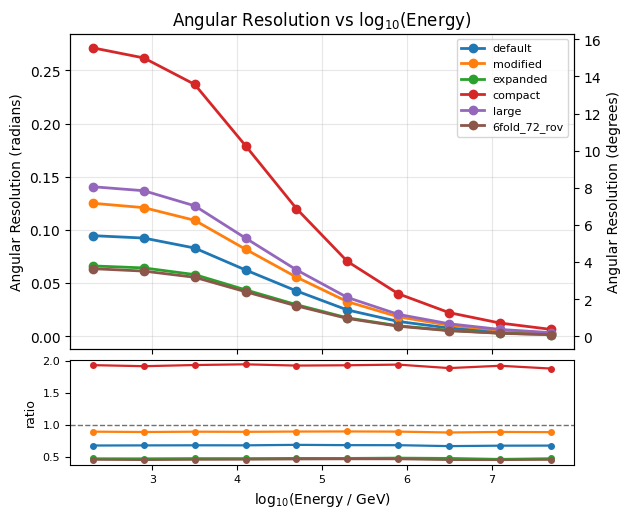

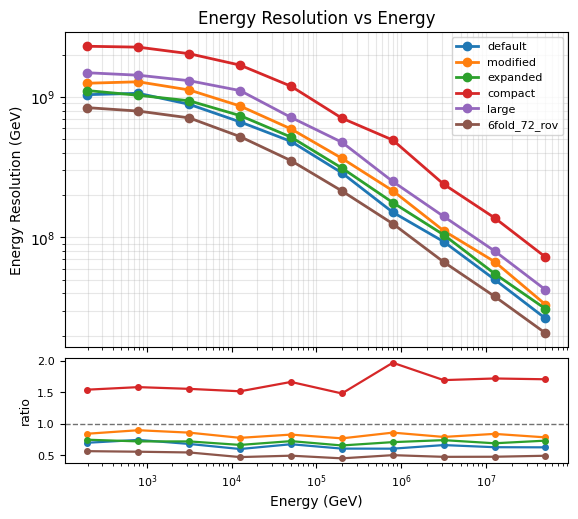

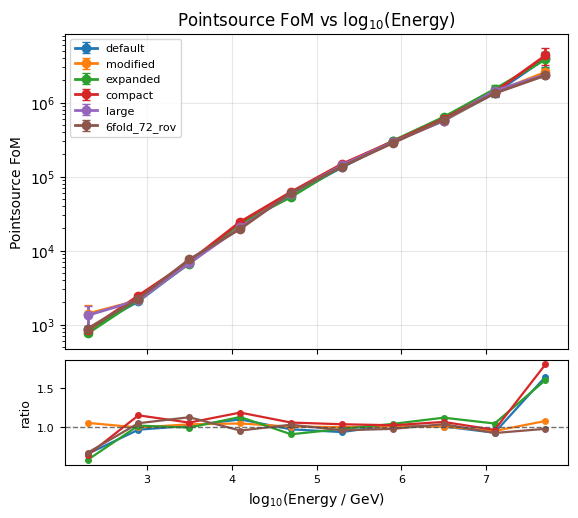

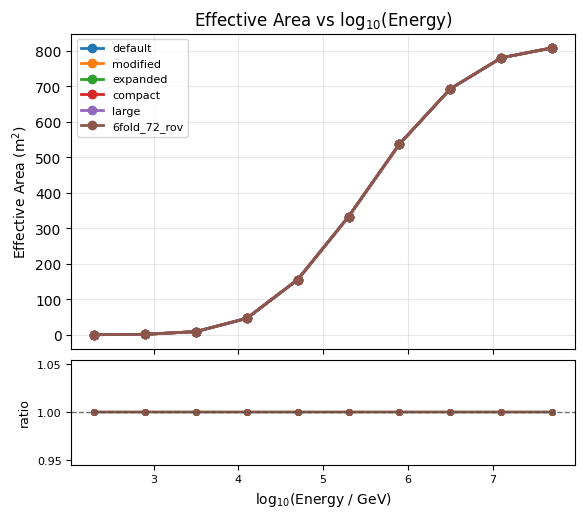

Eval[default] | rov_penalty: 0 | pointsource_fom_loss: 7.47434e-05 | energy_resolution_loss: 881254
Eval[modified] | rov_penalty: 0.0466038 | pointsource_fom_loss: 0.000105519 | energy_resolution_loss: 971077
Eval[expanded] | rov_penalty: 0 | pointsource_fom_loss: 7.52361e-05 | energy_resolution_loss: 902333
Eval[compact] | rov_penalty: 0.795147 | pointsource_fom_loss: 6.85542e-05 | energy_resolution_loss: 1.44389e+06
Eval[large] | rov_penalty: 0 | pointsource_fom_loss: 0.000109977 | energy_resolution_loss: 1.07246e+06
Eval[6fold_72_rov] | rov_penalty: 0 | pointsource_fom_loss: 0.000114046 | energy_resolution_loss: 804294


In [32]:
result =evaluator.evaluate_multi(
    geom_dicts=geom_dicts,
    loss_func_dict=loss_func_dict,
    loss_params_dicts=loss_param_dicts,
    vis_kwargs=vis_kwargs,
    visualize=True,
    clear_cuda_cache=True
)

In [11]:
# for key in geom_dicts.keys():
for key in ['800main_full_hex_rov',]:
    print(key)

    # calculate distances of each active string from every other string in 2d
    weights = torch.sigmoid(geom_dicts[key]['string_weights'])
    xy = geom_dicts[key]['string_xy']
    active_indices = torch.where(weights > 0.7)[0]
    active_xy = xy[active_indices]

    dists = active_xy.unsqueeze(1) - active_xy.unsqueeze(0)
    dists = torch.norm(dists, dim=-1)

    print(
        'Average distance between 5 nearest neighbors of active strings:',
        torch.topk(dists, k=6, largest=False).values[:, 1:].mean().item()
    )
    print('Mininmum distance between active strings:', dists[dists > 0].min().item())

    # center and average radius using all active points
    center = torch.mean(active_xy, dim=0)
    print('Center of active strings:', center.cpu().numpy())
    avg_radius = torch.norm(active_xy - center, dim=-1).mean().item()
    print('Average radius (all active points):', avg_radius)

    # average radius using only outer-most points (convex hull vertices)
    active_xy_np = active_xy.detach().cpu().numpy()
    center_np = center.detach().cpu().numpy()

    if active_xy_np.shape[0] >= 3:
        try:
            hull = scipy.spatial.ConvexHull(active_xy_np)
            outer_xy_np = active_xy_np[hull.vertices]
        except Exception:
            outer_xy_np = active_xy_np
    else:
        outer_xy_np = active_xy_np

    outer_avg_radius = np.linalg.norm(outer_xy_np - center_np, axis=1).mean()
    print('Average radius (outer-most points):', float(outer_avg_radius))
    

800main_full_hex_rov
Average distance between 5 nearest neighbors of active strings: 145.12110900878906
Mininmum distance between active strings: 44.44441604614258
Center of active strings: [-17.14286   20.894583]
Average radius (all active points): 404.2510681152344
Average radius (outer-most points): 628.6011352539062


mean x position: 1.9323043333292007
mean y position: 4.147034381818771


Text(0, 0.5, 'Y Position (m)')

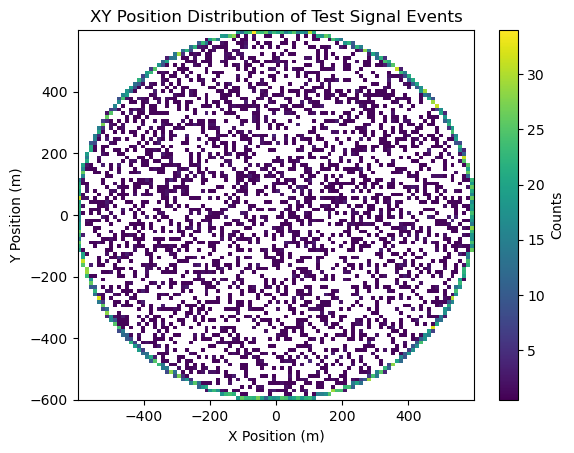

In [8]:
# create a heatmap of the xy positions of the events, make counts 0 white
new_test_signal_events = signal_sampler.sample_events(num_events=10000)
x_positions = [event['position'][0][0].item() for event in new_test_signal_events]
y_positions = [event['position'][0][1].item() for event in new_test_signal_events]

print('mean x position:', np.mean(x_positions))
print('mean y position:', np.mean(y_positions))
cmap = plt.cm.viridis.copy()
cmap.set_under('white')  # values below vmin -> white

plt.hist2d(x_positions, y_positions, bins=100, cmap=cmap, vmin=0.5)
plt.colorbar(label='Counts')
plt.title('XY Position Distribution of Test Signal Events')
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')


Using 6 / 6 geometries from res_test/opt_geoms/opt_geoms_dyn_61_inf_r600_50_poisson_no_rov_track_angle_mean_vertical


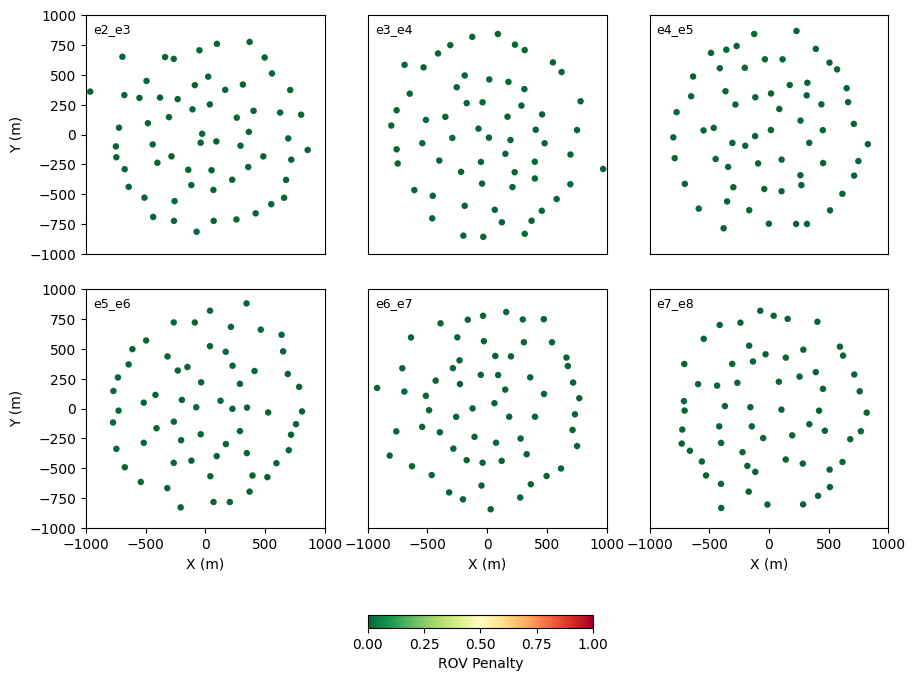

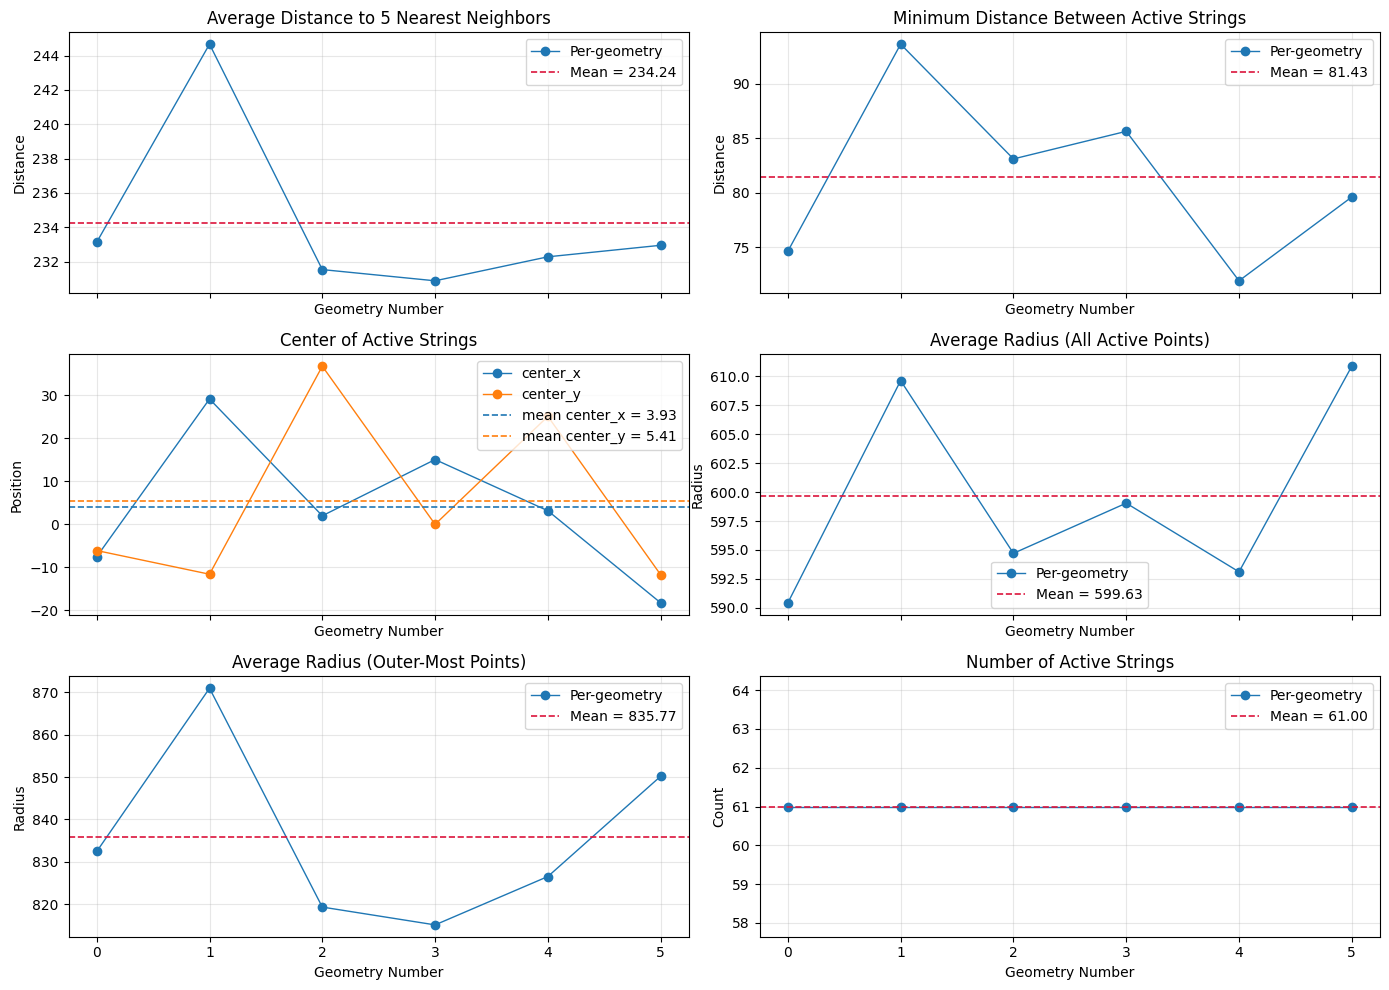

In [6]:
# Display all geometries from one folder and summarize per-geometry stats
from pathlib import Path
from scipy.spatial import ConvexHull

device='cuda:2'
# Folder containing geom_*.pkl files
geom_folder = Path("res_test/opt_geoms/opt_geoms_dyn_61_inf_r600_50_poisson_no_rov_track_angle_mean_vertical")
num_angles = 360
num_cols = 3
zoom_range = 1000
# Number of geometries to plot/analyze
# Set to None (or <=0) to use all geometries
num_geometries_to_pick = None

if not geom_folder.exists():
    raise FileNotFoundError(f"Folder not found: {geom_folder}")

# Ensure we have an ROV penalty object
rov_loss = nugget.losses.geometry_penalties.ROVPenalty(
    device=device,
    rov_rec_width=230,
    rov_height=160,
    rov_tri_length=160,
)

# Sort geometries by the numeric suffix in geom_<idx>.pkl
all_geom_paths = sorted(
    [p for p in geom_folder.glob("geom_e*.pkl")],
    key=lambda p: int(p.stem.split("_e")[1]),
)

# do not include geoms with _e in the name, only include geoms with geom_*.pkl
# all_geom_paths = [p for p in geom_folder.glob("geom_*.pkl") if "_e" not in p.stem]





# Randomly subsample geometries if requested
total_geoms = len(all_geom_paths)
if num_geometries_to_pick is None or num_geometries_to_pick <= 0 or num_geometries_to_pick >= total_geoms:
    geom_paths = all_geom_paths
else:
    pick_indices = np.random.choice(total_geoms, size=num_geometries_to_pick, replace=False)
    geom_paths = [all_geom_paths[int(i)] for i in pick_indices]

print(f"Using {len(geom_paths)} / {total_geoms} geometries from {geom_folder}")

# Preload geometry dicts and compute global color scale
geom_records = []
all_rov_penalties = []
for ind, geom_path in enumerate(geom_paths):
    # geom_idx = int(geom_path.stem.split("_")[1])
    geom_idx = ind  # Use sequential indices for display instead of original geom numbers
    geom_dict = pickle.load(open(geom_path, "rb"))
    # skip geometries with Nan string_weights (these are likely invalid geometries)
    # if "string_weights" not in geom_dict or torch.isnan(geom_dict["string_weights"]).any():
    #     continue  # Skip geometries without string_weights
    rov_per_string = (
        rov_loss(geom_dict, 
                num_angles=num_angles, 
                rov_alt_mode=True, 
                **{
                'detach_other_probs':True,
                'rov_soft_inside':False,
                'rov_angle_softmin_tau': -1,
                'rov_angle_chunk_size': 360,
                }
                 )["rov_penalty_per_string"]
        * len(geom_dict["string_xy"])
    )
    # print(f"Geometry {geom_idx}: ROV penalty per string: {rov_per_string.detach().cpu().numpy()}")
    all_rov_penalties.extend(rov_per_string.detach().cpu().numpy().ravel().clip(0, np.inf))  # Clip to avoid negative values due to numerical issues

    geom_records.append({
        "idx": geom_idx,
        "path": geom_path,
        "geom_dict": geom_dict,
        "rov_per_string": rov_per_string.clamp(min=0),  # Clamp to avoid negative values due to numerical issues
    })

if len(all_rov_penalties) == 0:
    raise RuntimeError("No ROV penalty values were computed")

vmin = 0
vmax = max(float(np.max(all_rov_penalties)), 1)

# --- Figure 1: geometry grid ---
num_geoms = len(geom_records)
num_rows = int(np.ceil(num_geoms / num_cols))

fig, axes = plt.subplots(
    nrows=num_rows,
    ncols=num_cols,
    figsize=(num_cols * 3, num_rows * 3.2),
    squeeze=False,
    sharex=True,
    sharey=True,
)

scatter = None
for plot_i in range(num_rows * num_cols):
    row_idx = plot_i // num_cols
    col_idx = plot_i % num_cols
    ax = axes[row_idx, col_idx]

    if plot_i >= num_geoms:
        ax.set_visible(False)
        continue

    record = geom_records[plot_i]
    geom_dict = record["geom_dict"]
    string_xy = geom_dict["string_xy"].detach().cpu().numpy()

    if "string_weights" in geom_dict:
        string_weights = geom_dict["string_weights"].detach().cpu().numpy()
        sig_weights = 1.0 / (1.0 + np.exp(-string_weights))
    else:
        sig_weights = np.ones(string_xy.shape[0], dtype=float)

    scatter = ax.scatter(
        string_xy[:, 0][sig_weights > 0.7],
        string_xy[:, 1][sig_weights > 0.7],
        c=record["rov_per_string"][sig_weights > 0.7].detach().cpu().numpy(),
        rasterized=True,
        alpha=sig_weights[sig_weights > 0.7],
        s=20,
        cmap="RdYlGn_r",
        vmin=0,
        vmax=vmax,
        edgecolors="k",
        linewidths=0.1,
    )
    ax.set_xlim([-zoom_range, zoom_range])
    ax.set_ylim([-zoom_range, zoom_range])
    ax.set_aspect("equal")

    # Show axis labels only on the left column and bottom row
    is_left_col = col_idx == 0
    is_bottom_row = row_idx == (num_rows - 1)
    ax.tick_params(
        axis="both",
        which="both",
        labelleft=is_left_col,
        labelbottom=is_bottom_row,
        left=is_left_col,
        bottom=is_bottom_row,
    )
    if is_left_col:
        ax.set_ylabel("Y (m)")
    if is_bottom_row:
        ax.set_xlabel("X (m)")

    # Put geometry number inside the subplot corner
    ax.text(
        0.03,
        0.97,
        # f"{record['idx']}",
        f"{all_geom_paths[plot_i].stem.split('geom_')[1]}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.7, "pad": 1.5},
    )

# Reserve bottom space first, then draw colorbar in a dedicated axis to avoid overlap
fig.tight_layout(rect=[0.0, 0.08, 1.0, 1.0], pad=0.15)
if scatter is not None:
    cax = fig.add_axes([0.40, 0.01, 0.25, 0.02])
    cbar = fig.colorbar(scatter, cax=cax, orientation="horizontal")
    cbar.set_label("ROV Penalty")
    cbar.set_ticks(np.linspace(0, vmax, 5))
    cbar.ax.set_xlim(0, vmax)
    # cbar.set_ticks(np.linspace(vmin, vmax, 5))

plt.show()

# --- Figure 2: per-geometry stats (same calculations as test_evaluation) ---
stats_idx = []
active_string_counts = []
avg_5nn = []
min_dist = []
center_x = []
center_y = []
avg_radius_all = []
avg_radius_outer = []

for record in geom_records:
    geom_dict = record["geom_dict"]

    xy = geom_dict["string_xy"]
    if "string_weights" in geom_dict:
        weights = torch.sigmoid(geom_dict["string_weights"])
        active_indices = torch.where(weights > 0.7)[0]
    else:
        active_indices = torch.arange(xy.shape[0], device=xy.device)

    active_xy = xy[active_indices]
    active_string_counts.append(int(active_xy.shape[0]))

    if active_xy.shape[0] < 2:
        stats_idx.append(record["idx"])
        avg_5nn.append(np.nan)
        min_dist.append(np.nan)
        center_x.append(np.nan)
        center_y.append(np.nan)
        avg_radius_all.append(np.nan)
        avg_radius_outer.append(np.nan)
        continue

    dists = active_xy.unsqueeze(1) - active_xy.unsqueeze(0)
    dists = torch.norm(dists, dim=-1)

    k_neighbors = min(6, active_xy.shape[0])
    nearest = torch.topk(dists, k=k_neighbors, largest=False).values[:, 1:]

    center = torch.mean(active_xy, dim=0)
    avg_radius = torch.norm(active_xy - center, dim=-1).mean().item()

    active_xy_np = active_xy.detach().cpu().numpy()
    center_np = center.detach().cpu().numpy()

    if active_xy_np.shape[0] >= 3:
        try:
            hull = ConvexHull(active_xy_np)
            outer_xy_np = active_xy_np[hull.vertices]
        except Exception:
            outer_xy_np = active_xy_np
    else:
        outer_xy_np = active_xy_np

    outer_avg_radius = np.linalg.norm(outer_xy_np - center_np, axis=1).mean()

    nonzero_d = dists[dists > 0]

    stats_idx.append(record["idx"])
    avg_5nn.append(nearest.mean().item() if nearest.numel() > 0 else np.nan)
    min_dist.append(nonzero_d.min().item() if nonzero_d.numel() > 0 else np.nan)
    center_x.append(float(center_np[0]))
    center_y.append(float(center_np[1]))
    avg_radius_all.append(float(avg_radius))
    avg_radius_outer.append(float(outer_avg_radius))

stats_idx = np.array(stats_idx)
order = np.argsort(stats_idx)
stats_idx = stats_idx[order]
active_string_counts = np.array(active_string_counts)[order]
avg_5nn = np.array(avg_5nn)[order]
min_dist = np.array(min_dist)[order]
center_x = np.array(center_x)[order]
center_y = np.array(center_y)[order]
avg_radius_all = np.array(avg_radius_all)[order]
avg_radius_outer = np.array(avg_radius_outer)[order]

# Means for horizontal reference lines
active_string_count_mean = float(np.nanmean(active_string_counts))
avg_5nn_mean = float(np.nanmean(avg_5nn))
min_dist_mean = float(np.nanmean(min_dist))
center_x_mean = float(np.nanmean(center_x))
center_y_mean = float(np.nanmean(center_y))
avg_radius_all_mean = float(np.nanmean(avg_radius_all))
avg_radius_outer_mean = float(np.nanmean(avg_radius_outer))

fig2, axes2 = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axes2 = axes2.ravel()

axes2[0].plot(stats_idx, avg_5nn, marker="o", linewidth=1, label="Per-geometry")
axes2[0].axhline(avg_5nn_mean, color="crimson", linestyle="--", linewidth=1.2, label=f"Mean = {avg_5nn_mean:.2f}")
axes2[0].set_title("Average Distance to 5 Nearest Neighbors")
axes2[0].set_ylabel("Distance")
axes2[0].grid(alpha=0.3)
axes2[0].legend()

axes2[1].plot(stats_idx, min_dist, marker="o", linewidth=1, label="Per-geometry")
axes2[1].axhline(min_dist_mean, color="crimson", linestyle="--", linewidth=1.2, label=f"Mean = {min_dist_mean:.2f}")
axes2[1].set_title("Minimum Distance Between Active Strings")
axes2[1].set_ylabel("Distance")
axes2[1].grid(alpha=0.3)
axes2[1].legend()

axes2[2].plot(stats_idx, center_x, marker="o", linewidth=1, label="center_x")
axes2[2].plot(stats_idx, center_y, marker="o", linewidth=1, label="center_y")
axes2[2].axhline(center_x_mean, color="tab:blue", linestyle="--", linewidth=1.2, label=f"mean center_x = {center_x_mean:.2f}")
axes2[2].axhline(center_y_mean, color="tab:orange", linestyle="--", linewidth=1.2, label=f"mean center_y = {center_y_mean:.2f}")
axes2[2].set_title("Center of Active Strings")
axes2[2].set_ylabel("Position")
axes2[2].legend()
axes2[2].grid(alpha=0.3)

axes2[3].plot(stats_idx, avg_radius_all, marker="o", linewidth=1, label="Per-geometry")
axes2[3].axhline(avg_radius_all_mean, color="crimson", linestyle="--", linewidth=1.2, label=f"Mean = {avg_radius_all_mean:.2f}")
axes2[3].set_title("Average Radius (All Active Points)")
axes2[3].set_ylabel("Radius")
axes2[3].grid(alpha=0.3)
axes2[3].legend()

axes2[4].plot(stats_idx, avg_radius_outer, marker="o", linewidth=1, label="Per-geometry")
axes2[4].axhline(avg_radius_outer_mean, color="crimson", linestyle="--", linewidth=1.2, label=f"Mean = {avg_radius_outer_mean:.2f}")
axes2[4].set_title("Average Radius (Outer-Most Points)")
axes2[4].set_xlabel("Geometry Number")
axes2[4].set_ylabel("Radius")
axes2[4].grid(alpha=0.3)
axes2[4].legend()

axes2[5].plot(stats_idx, active_string_counts, marker="o", linewidth=1, label="Per-geometry")
axes2[5].axhline(active_string_count_mean, color="crimson", linestyle="--", linewidth=1.2, label=f"Mean = {active_string_count_mean:.2f}")
axes2[5].set_title("Number of Active Strings")
axes2[5].set_ylabel("Count")
axes2[5].grid(alpha=0.3)
axes2[5].legend()

for ax in axes2:
    ax.set_xlabel("Geometry Number")

fig2.tight_layout()
plt.show()

In [4]:
all_geom_paths[0]

[PosixPath('res_test/opt_geoms/opt_geoms_full_hex_50000_r600_50_u_1_rov/geom_6.pkl'),
 PosixPath('res_test/opt_geoms/opt_geoms_full_hex_50000_r600_50_u_1_rov/geom_4.pkl'),
 PosixPath('res_test/opt_geoms/opt_geoms_full_hex_50000_r600_50_u_1_rov/geom_11.pkl'),
 PosixPath('res_test/opt_geoms/opt_geoms_full_hex_50000_r600_50_u_1_rov/geom_7.pkl'),
 PosixPath('res_test/opt_geoms/opt_geoms_full_hex_50000_r600_50_u_1_rov/geom_8.pkl'),
 PosixPath('res_test/opt_geoms/opt_geoms_full_hex_50000_r600_50_u_1_rov/geom_3.pkl'),
 PosixPath('res_test/opt_geoms/opt_geoms_full_hex_50000_r600_50_u_1_rov/geom_0.pkl'),
 PosixPath('res_test/opt_geoms/opt_geoms_full_hex_50000_r600_50_u_1_rov/geom_9.pkl'),
 PosixPath('res_test/opt_geoms/opt_geoms_full_hex_50000_r600_50_u_1_rov/geom_10.pkl'),
 PosixPath('res_test/opt_geoms/opt_geoms_full_hex_50000_r600_50_u_1_rov/geom_5.pkl'),
 PosixPath('res_test/opt_geoms/opt_geoms_full_hex_50000_r600_50_u_1_rov/geom_1.pkl'),
 PosixPath('res_test/opt_geoms/opt_geoms_full_hex_50

In [ ]:
num_events = 10000
# version = 'r600_50_1_c'
version = 'r600_50_4'

lightsabre_surrogate = nugget.surrogates.LightSabre.LightSabre(use_poisson=True, domain_size=1600, particle_mode = 'track')
light_yield_surrogate = lightsabre_surrogate.light_yield_surrogate

signal_events = pickle.load(open(f'/u/kristiantcho/ptmp/nugget/nugget/examples/res_test/signal_events_{num_events}_{version}.pkl', 'rb'))

angular_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    resolution_type='angular',
    fisher_info_params=['position','energy', 'direction']
)
energy_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    resolution_type='energy',
    fisher_info_params=['position','energy', 'direction']
)

loss_params = {
'signal_surrogate_func': light_yield_surrogate,
'perfect_efficiency': False,
'skip_zero_response': True,
# 'fisher_info_llr_net': llr_net,
'use_relative_energy': True,
'num_events':10000,
'signal_event_params': signal_events,

# 'precomputed_fisher_info_per_string_per_event': torch.load('/u/kristiantcho/ptmp/nugget/nugget/examples/res_test_fisher_info_per_string_per_event_100_base_geom_2.pt')
}
energy_loss_dicts = []
angular_loss_dicts = []
for string_spacing in np.linspace(25,200,20):
    geometry = nugget.geometries.SpaceString.SpaceString(
            hex_type='hexagonal',
            domain_size=2500,  # Size of detector domain
            # device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),  # Use GPU if available
            dim=3,  # 3D geometry
            n_strings=61,  # Initial number of detector strings
            points_per_string=20,  # Number of PMTs/sensors per string
            # starting_weight=-0.5,  # Initial weight for each string (controls visibility)
            # custom_string_spacing=0.09  # Custom spacing between strings
            starting_spacing=string_spacing,
            starting_z_spacing=50
        )
    geom_dict = geometry.initialize_points()
    try:
        precomputed_fisher_info = torch.load(f'res_test/space_test/fisher_info_per_string_per_event_{num_events}_{int(string_spacing)}_{version}.pt')
        loss_params['precomputed_fisher_info_per_string_per_event'] = precomputed_fisher_info
    except FileNotFoundError:
        continue

    energy_loss_dict = energy_resolution_loss(geom_dict, **loss_params)
    angular_loss_dict = angular_resolution_loss(geom_dict, **loss_params)
    energy_loss_dicts.append(energy_loss_dict)
    angular_loss_dicts.append(angular_loss_dict)


/ptmp/mpp/kristiantcho/nugget/nugget/losses/fisher_info.py:856: UserWarning: Use of index_put_ on expanded tensors is deprecated. Please clone() the tensor before performing this operation. This also applies to advanced indexing e.g. tensor[indices] = tensor (Triggered internally at /pytorch/aten/src/ATen/native/TensorAdvancedIndexing.cpp:967.)
  ref[parallel_mask] = torch.tensor([1.0, 0.0, 0.0], dtype=dtype, device=device)


/tmp/ipykernel_2095131/1268237430.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  energy_foms = np.array([np.median(np.array(loss_dict['resolution_per_event'])) for loss_dict in energy_loss_dicts])


Text(0, 0.5, 'Mean (relative) Energy Resolution')

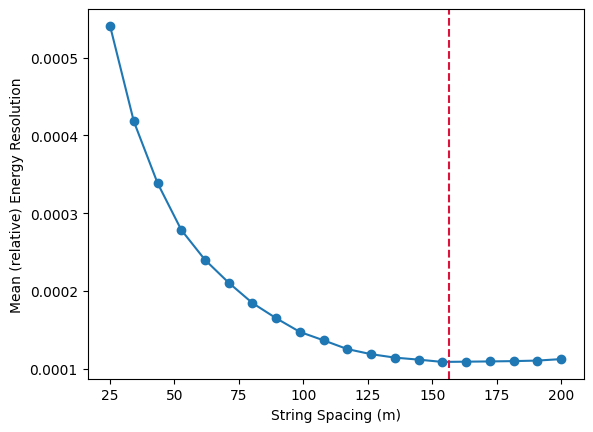

In [13]:

energy_foms = np.array([np.median(np.array(loss_dict['resolution_per_event'])) for loss_dict in energy_loss_dicts])
spacings = np.linspace(25,200,20)[:len(energy_foms)]
plt.plot(spacings, energy_foms, marker='o')
#plot bands for 2sigma confidence interval of the per-event resolutions
energy_stds = []
# for loss_dict in energy_loss_dicts:
#     resolutions = np.array(loss_dict['resolution_per_event'])
#     mean = np.mean(resolutions)
#     std = np.std(resolutions)
#     energy_stds.append(std)
# energy_stds = np.array(energy_stds)
# plt.fill_between(spacings, np.clip(energy_foms - 2*energy_stds, a_min=0, a_max=None), energy_foms + 2*energy_stds, color='blue', alpha=0.2)
f = scipy.interpolate.interp1d(spacings, energy_foms, kind='cubic')
# Create a finer spacing array for interpolation
fine_spacings = np.linspace(spacings.min(), spacings.max(), 1000)
fine_energy_foms = f(fine_spacings)

spacing_min = fine_spacings[np.argmin(fine_energy_foms)]
plt.axvline(spacing_min, color='crimson', linestyle='--', label=f'Min Energy Res at {spacing_min:.1f} m')
plt.xlabel('String Spacing (m)')
# plt.ylabel('Mean Angular Resolution (degrees)')
plt.ylabel('Mean (relative) Energy Resolution')

/tmp/ipykernel_2095131/466582374.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  angular_foms = np.array([np.median(np.array(loss_dict['resolution_per_event'])) for loss_dict in angular_loss_dicts])*180/np.pi


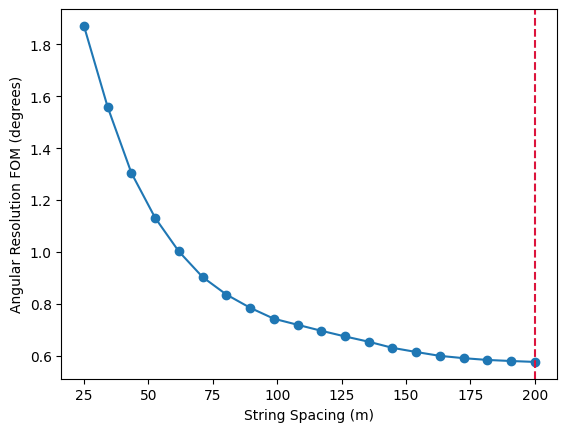

In [ ]:
# angular_foms = np.array([np.median(np.array(loss_dict['resolution_per_event'])) for loss_dict in angular_loss_dicts])*180/np.pi
angular_foms = np.array([loss_dict['angular_resolution_loss'] for loss_dict in angular_loss_dicts])*180/np.pi
spacings = np.linspace(25,200,20)[:len(angular_foms)]
plt.plot(spacings, angular_foms, marker='o')
plt.xlabel('String Spacing (m)')
plt.ylabel('Angular Resolution FOM (degrees)')
# plt.yscale('log')
#interpolate the angular_foms to find the string spacing that achieves minimum angular resolution

f = scipy.interpolate.interp1d(spacings, angular_foms, kind='cubic')
# Create a finer spacing array for interpolation
fine_spacings = np.linspace(spacings.min(), spacings.max(), 1000)
fine_angular_foms = f(fine_spacings)

spacing_min = fine_spacings[np.argmin(fine_angular_foms)]
plt.axvline(spacing_min, color='crimson', linestyle='--', label=f'Min Angular Res at {spacing_min:.1f} m')

In [2]:
from pathlib import Path
import re

import torch

fisher_info_dir = Path("res_test/space_test/r600_50_u_1_patd")
shard_pattern = re.compile(
    r"^(?P<prefix>fisher_info_per_string_per_event_.+?)_shard(?P<shard>\d+)of(?P<num_shards>\d+)_events(?P<start>\d+)-(?P<stop>\d+)\.pt$"
)

sharded_files = []
for shard_path in fisher_info_dir.glob("fisher_info_per_string_per_event_*_shard*of*_events*-*.pt"):
    match = shard_pattern.match(shard_path.name)
    if match is None:
        continue
    sharded_files.append((match.group("prefix"), int(match.group("shard")), int(match.group("num_shards")), shard_path))

if len(sharded_files) == 0:
    raise FileNotFoundError(f"No sharded fisher info files found in {fisher_info_dir}")

for prefix in sorted({item[0] for item in sharded_files}):
    prefix_entries = [item for item in sharded_files if item[0] == prefix]
    prefix_entries.sort(key=lambda item: item[1])

    num_shards = prefix_entries[0][2]
    shard_indices = [item[1] for item in prefix_entries]
    if shard_indices != list(range(num_shards)):
        raise RuntimeError(
            f"Missing shards for {prefix}: found {shard_indices}, expected {list(range(num_shards))}"
        )

    shard_tensors = [torch.load(item[3], map_location="cpu") for item in prefix_entries]
    combined_tensor = torch.cat(shard_tensors, dim=0)

    combined_path = fisher_info_dir / f"{prefix}.pt"
    torch.save(combined_tensor, combined_path)
    print(
        f"Saved {combined_path.name} from {len(shard_tensors)} shards with shape {tuple(combined_tensor.shape)}"
    )

Saved fisher_info_per_string_per_event_50000_107_r600_50_u_1_patd.pt from 5 shards with shape (50000, 61, 7, 7)
Saved fisher_info_per_string_per_event_50000_117_r600_50_u_1_patd.pt from 5 shards with shape (50000, 61, 7, 7)
Saved fisher_info_per_string_per_event_50000_126_r600_50_u_1_patd.pt from 5 shards with shape (50000, 61, 7, 7)
Saved fisher_info_per_string_per_event_50000_135_r600_50_u_1_patd.pt from 5 shards with shape (50000, 61, 7, 7)
Saved fisher_info_per_string_per_event_50000_144_r600_50_u_1_patd.pt from 5 shards with shape (50000, 61, 7, 7)
Saved fisher_info_per_string_per_event_50000_153_r600_50_u_1_patd.pt from 5 shards with shape (50000, 61, 7, 7)
Saved fisher_info_per_string_per_event_50000_163_r600_50_u_1_patd.pt from 5 shards with shape (50000, 61, 7, 7)
Saved fisher_info_per_string_per_event_50000_172_r600_50_u_1_patd.pt from 5 shards with shape (50000, 61, 7, 7)
Saved fisher_info_per_string_per_event_50000_181_r600_50_u_1_patd.pt from 5 shards with shape (50000, 61

In [2]:
importlib.reload(nugget.utils.data_tools)
importlib.reload(nugget.losses.fisher_info)

version = 'r600_50_u_1'
# number of energy bins (log-spaced)
n_bins = 6
num_events = 50000
use_also_patd = True
divide_by_energy = True  # Whether to use relative energy resolution (divide by true energy) or absolute resolution
# signal_events = pickle.load(open(f'/u/kristiantcho/ptmp/nugget/nugget/examples/res_test/signal_events_{num_events}_{version}.pkl', 'rb'))
signal_events = nugget.utils.data_tools.load_signal_events_parquet(f'/u/kristiantcho/ptmp/nugget/nugget/examples/res_test/signal_events_{num_events}_{version}.pt')
# extract event energies from signal_events (handles tensors or scalars)
# version += '_lambda'
energies = np.array([float(np.asarray(evt['energy']).ravel()[0]) if hasattr(evt['energy'], 'numel') or hasattr(evt['energy'], 'shape') else float(evt['energy']) for evt in signal_events])
pos_mask = energies > 0
if not np.any(pos_mask):
    raise RuntimeError('No positive event energies available for binning')
emin = energies[pos_mask].min()
emax = energies.max()
bin_edges = np.logspace(np.log10(emin), np.log10(emax), n_bins + 1)
# spacings to evaluate (must match precomputed files naming)
spacings = np.linspace(25, 200, 20)
# container: (n_bins, n_spacings) to store scalar FOM (median angular resolution in degrees)
fom_per_bin = np.full((n_bins, len(spacings)), np.nan)
med_per_bin = np.full((n_bins, len(spacings)), np.nan)
# optional zenith split: vertical vs horizontal-like tracks
split_by_zenith = False
zenith_split = np.pi / 2
fom_per_bin_vertical = np.full((n_bins, len(spacings)), np.nan)
fom_per_bin_horizontal = np.full((n_bins, len(spacings)), np.nan)
use_mean_resolution = False  # If True, use mean instead of median for FOM 
use_median_resolution = True  # If True, use median instead of mean for FOM 

loss_params = {
# 'signal_surrogate_func': light_yield_surrogate,
'perfect_efficiency': False,
'skip_zero_response': True,
# 'fisher_info_llr_net': llr_net,
'use_relative_energy': True,
'num_events': num_events,
'signal_event_params': signal_events,
}

angular_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    resolution_type='angular',
    fisher_info_params=['position', 'energy', 'direction']
 )
energy_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    resolution_type='energy',
    fisher_info_params=['position', 'energy', 'direction']
 )

for i, spacing in enumerate(spacings):
    # build geometry for this spacing (same as used to precompute fisher info)
    geometry = nugget.geometries.SpaceString.SpaceString(
        hex_type='hexagonal',
        domain_size=2500,
        dim=3,
        n_strings=61,
        points_per_string=20,
        starting_spacing=spacing,
        starting_z_spacing=50,
    )
    geom_dict = geometry.initialize_points()

    # try to load precomputed fisher info matching this spacing
    fname = f'res_test/space_test/{version}/fisher_info_per_string_per_event_{num_events}_{int(spacing)}_{version}.pt'
    patd_fname = f'res_test/space_test/{version}_patd/fisher_info_per_string_per_event_{num_events}_{int(spacing)}_{version}_patd.pt'

    try:
        if use_also_patd:
            precomp = torch.load(patd_fname)
            # precomp += torch.load(fname)
        else:
            precomp = torch.load(fname)
    except FileNotFoundError:
        continue

    # If precomp is a dict with the tensor under a key, try to find it
    if isinstance(precomp, dict):
        for key_name in ['precomputed_fisher_info_per_string_per_event', 'fisher_info', 'data']:
            if key_name in precomp:
                precomp_t = precomp[key_name]
                break
        else:
            tensor_values = [value for value in precomp.values() if isinstance(value, torch.Tensor) or hasattr(value, 'shape')]
            precomp_t = tensor_values[0] if len(tensor_values) > 0 else precomp
    else:
        precomp_t = precomp

    # ensure tensor
    if not isinstance(precomp_t, torch.Tensor):
        try:
            precomp_t = torch.as_tensor(precomp_t)
        except Exception:
            continue

    event_axis = None
    for axis_index, axis_size in enumerate(precomp_t.shape):
        if axis_size == len(signal_events):
            event_axis = axis_index
            break
    if event_axis is None:
        event_axis = 1 if precomp_t.ndim > 1 else 0

    # for each energy bin, select events via the shared helpers and compute the loss
    for b in range(n_bins):
        energy_limits = {'energy': [float(bin_edges[b]), float(bin_edges[b + 1])] }
        bin_indices = nugget.utils.data_tools.select_event_indices(signal_events, energy_limits)
        if len(bin_indices) == 0:
            continue

        bin_signal_events = nugget.utils.data_tools.select_events(signal_events, energy_limits)
        bin_index_tensor = torch.as_tensor(bin_indices, dtype=torch.long, device=precomp_t.device)
        bin_precomp = torch.index_select(precomp_t, event_axis, bin_index_tensor)

        local_loss_params = dict(loss_params)
        local_loss_params['signal_event_params'] = bin_signal_events
        local_loss_params['num_events'] = int(len(bin_signal_events))
        local_loss_params['precomputed_fisher_info_per_string_per_event'] = bin_precomp

        loss_out = angular_resolution_loss(geom_dict, **local_loss_params)
        if use_mean_resolution and 'resolution_per_event' in loss_out:
            fom_per_bin[b, i] = float(torch.mean(loss_out['resolution_per_event'])) * 180.0 / np.pi
        elif use_median_resolution and 'resolution_per_event' in loss_out:
            fom_per_bin[b, i] = float(torch.median(loss_out['resolution_per_event'])) * 180.0 / np.pi
        else:
            if 'angular_resolution_loss' in loss_out:
                fom_per_bin[b, i] = float(loss_out['angular_resolution_loss']) * 180.0 / np.pi
            else:
                fom_per_bin[b, i] = np.nan

        if split_by_zenith:
            vertical_limits = {'zenith': 'vertical'}
            horizontal_limits = {'zenith': 'horizontal'}

            for subset_limits, target in [
                (vertical_limits, fom_per_bin_vertical),
                (horizontal_limits, fom_per_bin_horizontal),
            ]:
                subset_indices = nugget.utils.data_tools.select_event_indices(bin_signal_events, subset_limits)
                if len(subset_indices) == 0:
                    continue

                subset_events = nugget.utils.data_tools.select_events(bin_signal_events, subset_limits)
                subset_index_tensor = torch.as_tensor(subset_indices, dtype=torch.long, device=bin_precomp.device)
                subset_precomp = torch.index_select(bin_precomp, event_axis, subset_index_tensor)

                subset_loss_params = dict(local_loss_params)
                subset_loss_params['signal_event_params'] = subset_events
                subset_loss_params['num_events'] = int(len(subset_events))
                subset_loss_params['precomputed_fisher_info_per_string_per_event'] = subset_precomp

                subset_out = angular_resolution_loss(geom_dict, **subset_loss_params)
                if use_mean_resolution and 'resolution_per_event' in subset_out:
                    target[b, i] = float(torch.mean(subset_out['resolution_per_event'])) * 180.0 / np.pi
                else:   
                    if 'angular_resolution_loss' in subset_out:
                        target[b, i] = float(subset_out['angular_resolution_loss']) * 180.0 / np.pi

# Plot results: colorbar for energy bins and dashed vertical minima lines


/ptmp/mpp/kristiantcho/nugget/nugget/losses/fisher_info_helpers.py:1747: UserWarning: Use of index_put_ on expanded tensors is deprecated. Please clone() the tensor before performing this operation. This also applies to advanced indexing e.g. tensor[indices] = tensor (Triggered internally at /pytorch/aten/src/ATen/native/TensorAdvancedIndexing.cpp:967.)
  ref[parallel_mask] = torch.tensor([1.0, 0.0, 0.0], dtype=dtype, device=device)


In [6]:
test_tensor = torch.sum(precomp.sum(dim=3), dim=2) > 0
# filter events to only those with non-zero fisher info across all strings
mask = test_tensor.all(dim=(1))  # Keep only events where all strings have non-zero fisher info
print(mask.sum().item(), "events with non-zero fisher info across all strings")

48759 events with non-zero fisher info across all strings


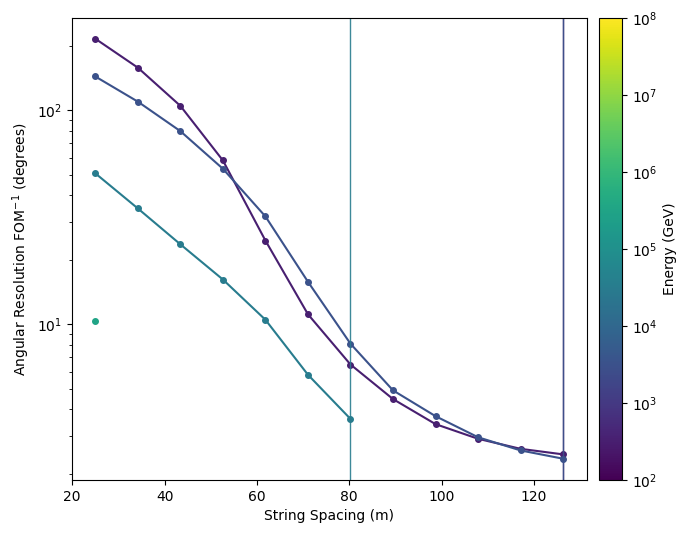

In [3]:
plt.figure(figsize=(8, 6))
ax = plt.gca()
# compute geometric bin centers for log-scaled energy coloring
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
log_centers = np.log10(bin_centers)
# force colorbar to span from 10^2 to 10^8 GeV with full color gradient
norm = plt.Normalize(2, 8)
cmap = plt.cm.viridis
mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
# give the mappable a real array so colorbar can infer scale
mappable.set_array(log_centers)
colors = mappable.to_rgba(log_centers)

use_split_by_zenith = bool(globals().get('split_by_zenith', False))
if use_split_by_zenith:
    track_series = [
        ('vertical', fom_per_bin_vertical, '-'),
        ('horizontal', fom_per_bin_horizontal, '--'),
    ]
else:
    track_series = [
        ('all', fom_per_bin, '-'),
    ]

for b in range(n_bins):
    # if b != 5:
    #     continue
    for track_name, series_matrix, linestyle in track_series:
        series = series_matrix[b]
        valid = np.isfinite(series)
        if not np.any(valid):
            continue

        ax.plot(
            spacings[valid],
            series[valid],
            marker='o',
            color=colors[b],
            markersize=4,
            linestyle=linestyle,
        )

        if np.count_nonzero(valid) >= 2:
            xvals = spacings[valid]
            yvals = series[valid]
            interp_kind = 'cubic' if np.count_nonzero(valid) >= 4 else 'linear'
            f = scipy.interpolate.interp1d(xvals, yvals, kind=interp_kind)
            fine_spacings = np.linspace(xvals.min(), xvals.max(), 1000)
            fine_vals = f(fine_spacings)
            spacing_min = fine_spacings[np.argmin(fine_vals)]
            ax.axvline(spacing_min, color=colors[b], linestyle=linestyle, linewidth=1.0, alpha=0.9)

# colorbar: show energies (labels in scientific notation). attach to the axes
cbar = plt.colorbar(mappable, ax=ax, pad=0.02)
ax.set_yscale('log')
# force fixed ticks from 10^2 to 10^8 GeV
ticks = np.arange(2, 9)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f'$10^{{{int(t)}}}$' for t in ticks])
cbar.set_label('Energy (GeV)')
ax.set_xlabel('String Spacing (m)')
# ax.set_ylabel(r'Angular Resolution (degrees)')
ax.set_ylabel(r'Angular Resolution FOM$^{-1}$ (degrees)')
# ax.grid(True)
plt.show()

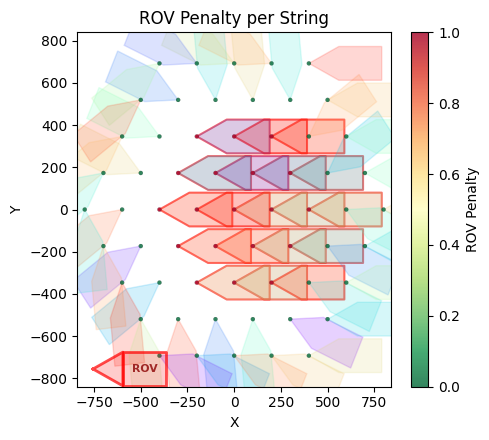

No valid losses returned.


In [ ]:
# for spacing in range(25, 300):
visualizer = nugget.utils.vis_tools.Visualizer(
    dim=3, 
    domain_size=500,
    )
rov_loss = nugget.losses.geometry_penalties.ROVPenalty(
    rov_rec_width=230,
    rov_height=160,
    rov_tri_length=160,
)
spacing = 200
geometry = nugget.geometries.SpaceString.SpaceString(
        hex_type='hexagonal',
        domain_size=2500,
        dim=3,
        n_strings=61,
        points_per_string=20,
        starting_spacing=spacing,
        starting_z_spacing=50,
    )
geom_dict = geometry.initialize_points()
# rov_sum =rov_loss(geom_dict, 
#                 num_angles=360, 
#                 rov_alt_mode=True, 
#                 **{
#                 'detach_other_probs':True,
#                 'rov_soft_inside':False,
#                 'rov_angle_softmin_tau': -1,
#                 'rov_angle_chunk_size': 360,
#                 }
#                 )["rov_penalty_per_string"]*len(geom_dict["string_xy"])

loss_params = { 'num_angles': 360, 
                'rov_alt_mode':False, 
                'detach_other_probs':True,
                'rov_soft_inside':False,
                'rov_angle_softmin_tau': -1,
                'rov_angle_chunk_size': 360,
                }



loss_func_dict = {
    'rov_loss': rov_loss,
    }

plot_types = [
    'string_xy_rov_penalty',
]
# additional arguments for the visualizer
vis_kwargs = {
    'plot_types': plot_types,
    
    'rov_penalty_func': rov_loss,
    'use_relative_energy': True,
    'plot_geom_contour_only': True,
    'use_log_charge': True,
    'rov_draw_safe_space_union': True,
    'rov_union_per_space_colors':True,
    'rov_draw_safe_space_on_violations':True,
}
evaluator = nugget.utils.basic_evaluator.Evaluator(
    geometry=geometry,
    visualizer=visualizer,
)

result =evaluator.evaluate(
    geom_dict=geom_dict,
    # geom_dict=pickle.load(open('./rov_centered_r800_ang_res_double/geom_9.pkl', 'rb')),
    loss_func_dict=loss_func_dict,
    loss_params_dict=loss_params,
    vis_kwargs=vis_kwargs,
    visualize=True,
)



Found 5 file-level bin(s): [(2, 3, 'horizontal'), (3, 4, 'horizontal'), (4, 5, 'horizontal'), (5, 6, 'horizontal'), (6, 8, 'horizontal')]
Plotting 3 logical bin(s): ['e2-4', 'e4-6', 'e6-8 horizontal']
  Loaded 1000 events for e2-3 horizontal
  Loaded 1000 events for e3-4 horizontal


/ptmp/mpp/kristiantcho/nugget/nugget/losses/fisher_info_helpers.py:1839: UserWarning: Use of index_put_ on expanded tensors is deprecated. Please clone() the tensor before performing this operation. This also applies to advanced indexing e.g. tensor[indices] = tensor (Triggered internally at /pytorch/aten/src/ATen/native/TensorAdvancedIndexing.cpp:967.)
  ref[parallel_mask] = torch.tensor([1.0, 0.0, 0.0], dtype=dtype, device=device)


  Loaded 1000 events for e4-5 horizontal
  Loaded 1000 events for e5-6 horizontal


/ptmp/mpp/kristiantcho/nugget/nugget/losses/fisher_info_helpers.py:1839: UserWarning: Use of index_put_ on expanded tensors is deprecated. Please clone() the tensor before performing this operation. This also applies to advanced indexing e.g. tensor[indices] = tensor (Triggered internally at /pytorch/aten/src/ATen/native/TensorAdvancedIndexing.cpp:967.)
  ref[parallel_mask] = torch.tensor([1.0, 0.0, 0.0], dtype=dtype, device=device)


  Loaded 1000 events for e6-8 horizontal


/ptmp/mpp/kristiantcho/nugget/nugget/losses/fisher_info_helpers.py:1839: UserWarning: Use of index_put_ on expanded tensors is deprecated. Please clone() the tensor before performing this operation. This also applies to advanced indexing e.g. tensor[indices] = tensor (Triggered internally at /pytorch/aten/src/ATen/native/TensorAdvancedIndexing.cpp:967.)
  ref[parallel_mask] = torch.tensor([1.0, 0.0, 0.0], dtype=dtype, device=device)


Found 3 optimized geometry file(s): [(2, 4), (4, 6), (6, 8)]


/ptmp/mpp/kristiantcho/nugget/nugget/losses/fisher_info_helpers.py:1839: UserWarning: Use of index_put_ on expanded tensors is deprecated. Please clone() the tensor before performing this operation. This also applies to advanced indexing e.g. tensor[indices] = tensor (Triggered internally at /pytorch/aten/src/ATen/native/TensorAdvancedIndexing.cpp:967.)
  ref[parallel_mask] = torch.tensor([1.0, 0.0, 0.0], dtype=dtype, device=device)
/tmp/ipykernel_301455/1662587519.py:258: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  opt_fom = float(stat(opt_loss_out['resolution_per_event'])) * 180.0 / np.pi


  geom_e2_e4: FOM = 0.7514 deg (n_events=2000)
  geom_e4_e6: FOM = 0.4516 deg (n_events=2000)
  geom_e6_e8: FOM = 0.1741 deg (n_events=1000)


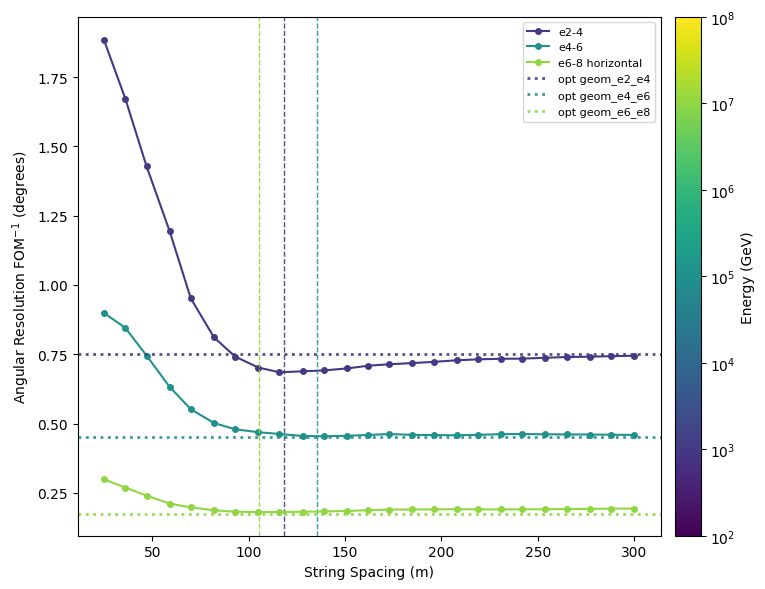

In [2]:


import re
from pathlib import Path

# ── User config ────────────────────────────────────────────────────────────────
manual_version      = "r600_50_u_sp_1"          # version string used in res_test_space_manual.py
manual_num_events   = 1000                        # num_events used when generating files
manual_zenith_range = "horizontal"               # zenith_range used (e.g. "horizontal", "vertical")
use_mean_resolution = False   # If True, use mean instead of median for FOM

# Which file-level energy bins to include.  Each entry is (lo, hi) matching e{lo}-{hi} filenames.
# Set to None to auto-discover and plot every bin found separately.
energy_bins_to_plot = None   # e.g. [(2, 3), (6, 8)]  or  None

combine_energy_bins = [[(2, 3), (3, 4)], [(4, 5), (5, 6)]]  # e.g. [[(2, 3), (3, 4)], [(6, 7), (7, 8)]]
# combine_energy_bins = None  # e.g. [[(2, 3), (3, 4)], [(6, 7), (7, 8)]]
use_patd_manual = False   # set True if files were generated with use_patd=True

opt_geoms_version = "r600_50_u_sp_1_horizontal"   # {version} used in res_test_make_geoms.py filenames
opt_geoms_num_events = 5000 
plot_opt_geoms = True   # set True to overlay optimized geometries
opt_geoms_folder = Path(f"res_test/opt_geoms/opt_geoms_full_hex_{opt_geoms_num_events}_{opt_geoms_version}_rov")
                     # num_events used in res_test_make_geoms.py
opt_geoms_signal_events_dir = Path("res_test/signal_events")
opt_geoms_fisher_info_dir = Path("res_test/fisher_info")
# ──────────────────────────────────────────────────────────────────────────────

version_dir = manual_version
if use_patd_manual:
    version_dir += "_patd"

fisher_dir = Path(f"res_test/space_test/{version_dir}")
if not fisher_dir.exists():
    raise FileNotFoundError(f"Directory not found: {fisher_dir}")

# Discover all (lo, hi, zenith) file-level bins present in the directory
file_pattern = re.compile(
    r"^fisher_info_per_string_per_event_(\d+)_(\d+)_e(\d+)-(\d+)_([^.]+)\.pt$"
)
found_bins = {}   # (lo, hi, zenith) -> {spacing_int: path}
for p in fisher_dir.glob("fisher_info_per_string_per_event_*.pt"):
    m = file_pattern.match(p.name)
    if not m:
        continue
    n_ev, spacing_int, e_lo, e_hi, zenith = int(m[1]), int(m[2]), int(m[3]), int(m[4]), m[5]
    if n_ev != manual_num_events:
        continue
    if zenith != manual_zenith_range:
        continue
    key = (e_lo, e_hi, zenith)
    found_bins.setdefault(key, {})[spacing_int] = p

if not found_bins:
    raise RuntimeError(f"No matching files found in {fisher_dir}")

# Apply energy bin filter (file-level)
if energy_bins_to_plot is not None:
    keep = {(lo, hi) for lo, hi in energy_bins_to_plot}
    found_bins = {k: v for k, v in found_bins.items() if (k[0], k[1]) in keep}
    if not found_bins:
        raise RuntimeError(f"None of the requested energy bins {energy_bins_to_plot} were found")

print(f"Found {len(found_bins)} file-level bin(s): {sorted(found_bins.keys())}")

# Build sorted spacing array (union across all bins)
all_spacings_int = sorted({s for paths in found_bins.values() for s in paths.keys()})
spacings_manual = np.array(all_spacings_int, dtype=float)

# Build the list of logical bins to plot.
# Each logical bin is a dict with:
#   'label': str, 'log_center': float, 'file_keys': list of (lo, hi, zenith)
logical_bins = []

combined_file_keys = set()
if combine_energy_bins:
    for group in combine_energy_bins:
        file_keys = [(lo, hi, manual_zenith_range) for lo, hi in group]
        missing = [k for k in file_keys if k not in found_bins]
        if missing:
            print(f"  [warn] skipping merged bin {group}: missing file bins {missing}")
            continue
        e_lo_all = [lo for lo, hi in group]
        e_hi_all = [hi for lo, hi in group]
        label = f"e{min(e_lo_all)}-{max(e_hi_all)}"
        log_center = (min(e_lo_all) + max(e_hi_all)) / 2.0
        logical_bins.append({'label': label, 'log_center': log_center, 'file_keys': file_keys})
        combined_file_keys.update(file_keys)

# Any file-level bin not consumed by a combine group becomes its own logical bin
for key in sorted(found_bins.keys()):
    if key not in combined_file_keys:
        e_lo, e_hi, zenith = key
        logical_bins.append({
            'label': f"e{e_lo}-{e_hi} {zenith}",
            'log_center': (e_lo + e_hi) / 2.0,
            'file_keys': [key],
        })

print(f"Plotting {len(logical_bins)} logical bin(s): {[b['label'] for b in logical_bins]}")

# ── Compute FOM per logical bin per spacing ───────────────────────────────────
importlib.reload(nugget.losses.fisher_info)
importlib.reload(nugget.utils.data_tools)

angular_resolution_loss_manual = nugget.losses.fisher_info.WeightedResolutionLoss(
    resolution_type='angular',
    fisher_info_params=['energy', 'direction'],
)

# cache loaded signal events per file key so we don't reload for every spacing
_signal_events_cache = {}

def _load_signal_events(e_lo, e_hi, zenith):
    key = (e_lo, e_hi, zenith)
    if key not in _signal_events_cache:
        path = fisher_dir / f"signal_events_{manual_num_events}_e{e_lo}-{e_hi}_{zenith}.pt"
        if not path.exists():
            raise FileNotFoundError(f"Signal events not found: {path}")
        _signal_events_cache[key] = nugget.utils.data_tools.load_signal_events_parquet(str(path))
        print(f"  Loaded {len(_signal_events_cache[key])} events for e{e_lo}-{e_hi} {zenith}")
    return _signal_events_cache[key]

fom_manual = {}   # label -> np.array of shape (len(spacings_manual),)

for lbin in logical_bins:
    label = lbin['label']
    file_keys = lbin['file_keys']

    # pre-load all signal event lists for this logical bin
    try:
        events_per_key = {k: _load_signal_events(*k) for k in file_keys}
    except FileNotFoundError as e:
        print(f"  [skip] {label}: {e}")
        continue

    fom_row = np.full(len(spacings_manual), np.nan)

    for si, sp_int in enumerate(all_spacings_int):
        # collect precomp tensors and signal events across all file keys for this spacing
        merged_events = []
        merged_precomps = []

        for fkey in file_keys:
            e_lo, e_hi, zenith = fkey
            spacing_paths = found_bins[fkey]
            if sp_int not in spacing_paths:
                continue

            evs = events_per_key[fkey]
            precomp = torch.load(spacing_paths[sp_int], map_location='cpu')
            if not isinstance(precomp, torch.Tensor):
                vals = [v for v in (precomp.values() if isinstance(precomp, dict) else []) if isinstance(v, torch.Tensor)]
                precomp = vals[0] if vals else torch.as_tensor(precomp)

            # ensure event axis is 0 (cat along events)
            event_axis = next((ax for ax, sz in enumerate(precomp.shape) if sz == len(evs)), 0)
            if event_axis != 0:
                precomp = precomp.transpose(0, event_axis).contiguous()

            merged_events.extend(evs)
            merged_precomps.append(precomp)

        if not merged_events:
            continue

        merged_precomp = torch.cat(merged_precomps, dim=0) if len(merged_precomps) > 1 else merged_precomps[0]

        geometry_manual = nugget.geometries.SpaceString.SpaceString(
            hex_type='hexagonal',
            domain_size=2500,
            dim=3,
            n_strings=61,
            points_per_string=20,
            starting_spacing=float(sp_int),
            starting_z_spacing=50,
        )
        geom_dict_manual = geometry_manual.initialize_points()

        local_lp = {
            'perfect_efficiency': False,
            'skip_zero_response': True,
            'use_relative_energy': True,
            'num_events': len(merged_events),
            'signal_event_params': merged_events,
            'precomputed_fisher_info_per_string_per_event': merged_precomp,
        }

        loss_out = angular_resolution_loss_manual(geom_dict_manual, **local_lp)
        if 'resolution_per_event' in loss_out:
            stat = torch.mean if use_mean_resolution else torch.median
            fom_row[si] = float(stat(loss_out['resolution_per_event'])) * 180.0 / np.pi
        elif 'angular_resolution_loss' in loss_out:
            fom_row[si] = float(loss_out['angular_resolution_loss']) * 180.0 / np.pi

    fom_manual[label] = fom_row

# ── Optionally compute FOM for optimized geometries from res_test_make_geoms.py ─
# Each geom_e{lo}_e{hi}.pkl is scored against the signal_events/fisher_info files
# res_test_make_geoms.py used for that same (lo, hi) bin, i.e.:
#   {opt_geoms_signal_events_dir}/signal_events_{opt_geoms_num_events}_r600_50{opt_geoms_version}.pt
#   {opt_geoms_fisher_info_dir}/fisher_info_per_string_per_event_{opt_geoms_num_events}_800main_full_hex_r600_50{opt_geoms_version}.pt
# filtered down to the events whose energy falls in [10**lo, 10**hi].
opt_geom_results = []   # list of dicts: {'label', 'e_lo', 'e_hi', 'log_center', 'fom'}

if plot_opt_geoms:
    if not opt_geoms_folder.exists():
        raise FileNotFoundError(f"Optimized geometry folder not found: {opt_geoms_folder}")

    opt_geom_pattern = re.compile(r"^geom_e(\d+)_e(\d+)\.pkl$")
    opt_geom_paths = {}   # (lo, hi) -> path
    for p in opt_geoms_folder.glob("geom_e*_e*.pkl"):
        m = opt_geom_pattern.match(p.name)
        if not m:
            continue
        opt_geom_paths[(int(m[1]), int(m[2]))] = p

    if not opt_geom_paths:
        raise RuntimeError(f"No geom_e{{lo}}_e{{hi}}.pkl files found in {opt_geoms_folder}")

    print(f"Found {len(opt_geom_paths)} optimized geometry file(s): {sorted(opt_geom_paths.keys())}")

    opt_signal_events_path = opt_geoms_signal_events_dir / f"signal_events_{opt_geoms_num_events}_{opt_geoms_version}.pt"
    opt_fisher_info_path = opt_geoms_fisher_info_dir / f"fisher_info_per_string_per_event_{opt_geoms_num_events}_800main_full_hex_{opt_geoms_version}.pt"
    if not opt_signal_events_path.exists():
        raise FileNotFoundError(f"Signal events not found: {opt_signal_events_path}")
    if not opt_fisher_info_path.exists():
        raise FileNotFoundError(f"Fisher info not found: {opt_fisher_info_path}")

    opt_all_events = nugget.utils.data_tools.load_signal_events_parquet(str(opt_signal_events_path))
    opt_all_fisher_info = torch.load(opt_fisher_info_path, map_location='cpu')

    for (e_lo, e_hi), geom_path in sorted(opt_geom_paths.items()):
        selection_limits = {'energy': (10 ** e_lo, 10 ** e_hi)}
        selection_inds = nugget.utils.data_tools.select_event_indices(opt_all_events, limits=selection_limits)
        if len(selection_inds) == 0:
            print(f"  [skip] geom_e{e_lo}_e{e_hi}: no events in range 10^{e_lo}-10^{e_hi}")
            continue

        opt_events = nugget.utils.data_tools.select_events(opt_all_events, limits=selection_limits)
        opt_fisher_info = opt_all_fisher_info[selection_inds]

        opt_geom_dict = pickle.load(open(geom_path, "rb"))
        for key in opt_geom_dict:
            if isinstance(opt_geom_dict[key], torch.Tensor):
                opt_geom_dict[key] = opt_geom_dict[key].to('cpu')

        opt_local_lp = {
            'perfect_efficiency': False,
            'skip_zero_response': True,
            'use_relative_energy': True,
            'num_events': len(opt_events),
            'signal_event_params': opt_events,
            'precomputed_fisher_info_per_string_per_event': opt_fisher_info,
        }

        opt_loss_out = angular_resolution_loss_manual(opt_geom_dict, **opt_local_lp)
        if 'resolution_per_event' in opt_loss_out:
            stat = torch.mean if use_mean_resolution else torch.median
            opt_fom = float(stat(opt_loss_out['resolution_per_event'])) * 180.0 / np.pi
        elif 'angular_resolution_loss' in opt_loss_out:
            opt_fom = float(opt_loss_out['angular_resolution_loss']) * 180.0 / np.pi
        else:
            print(f"  [skip] geom_e{e_lo}_e{e_hi}: loss output missing expected keys")
            continue

        opt_geom_results.append({
            'label': f"opt geom_e{e_lo}_e{e_hi}",
            'e_lo': e_lo,
            'e_hi': e_hi,
            'log_center': (e_lo + e_hi) / 2.0,
            'fom': opt_fom,
        })
        print(f"  geom_e{e_lo}_e{e_hi}: FOM = {opt_fom:.4f} deg (n_events={len(opt_events)})")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig_m, ax_m = plt.subplots(figsize=(8, 6))

norm_m = plt.Normalize(2, 8)
cmap_m = plt.cm.viridis
mappable_m = plt.cm.ScalarMappable(norm=norm_m, cmap=cmap_m)
mappable_m.set_array([])

for lbin in logical_bins:
    label = lbin['label']
    if label not in fom_manual:
        continue
    series = fom_manual[label]
    valid = np.isfinite(series)
    if not np.any(valid):
        continue

    color = mappable_m.to_rgba(lbin['log_center'])

    ax_m.plot(spacings_manual[valid], series[valid], marker='o', color=color,
              markersize=4, linestyle='-', label=label)

    if np.count_nonzero(valid) >= 2:
        xv, yv = spacings_manual[valid], series[valid]
        kind = 'cubic' if np.count_nonzero(valid) >= 4 else 'linear'
        f_interp = scipy.interpolate.interp1d(xv, yv, kind=kind)
        fine_x = np.linspace(xv.min(), xv.max(), 1000)
        fine_y = f_interp(fine_x)
        sp_min = fine_x[np.argmin(fine_y)]
        ax_m.axvline(sp_min, color=color, linestyle='--', linewidth=1.0, alpha=0.9)

for opt_result in opt_geom_results:
    color = mappable_m.to_rgba(opt_result['log_center'])
    ax_m.axhline(
        opt_result['fom'],
        color=color,
        linestyle=':',
        linewidth=2.0,
        alpha=0.9,
        label=opt_result['label'],
    )

cbar_m = plt.colorbar(mappable_m, ax=ax_m, pad=0.02)
# ax_m.set_yscale('log')
ticks_m = np.arange(2, 9)
cbar_m.set_ticks(ticks_m)
cbar_m.set_ticklabels([f'$10^{{{int(t)}}}$' for t in ticks_m])
cbar_m.set_label('Energy (GeV)')
ax_m.set_xlabel('String Spacing (m)')
ax_m.set_ylabel(r'Angular Resolution FOM$^{-1}$ (degrees)')
ax_m.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()